In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
import pandas_ta
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline
import talib

from position_tools import calculate_trades, calculate_positions, count_since_last_signal

from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
import numpy as np
import sysconfig
f'gcc -shared -o positions.so -fPIC positions.c -I{sysconfig.get_path("include")} -I{np.get_include()}'

'gcc -shared -o positions.so -fPIC positions.c -I/home/mu6mula/miniconda3/envs/py310/include/python3.10 -I/home/mu6mula/miniconda3/envs/py310/lib/python3.10/site-packages/numpy/core/include'

In [14]:
param_defs = {
    # 'ema_short_period': {'method': 'suggest_int', 'min': 10, 'max': 60},
    # 'ema_long_period': {
    #     'method': 'suggest_int', 
    #     'min': 61, 
    #     'max': 200,
    #     'min_depends_on': {
    #         'param': 'ema_short_period',
    #         'adjust_min': lambda ema_short: ema_short + 1
    #     }
    # },
    # 'ewo_thre_long': {'method': 'suggest_float', 'min': 0.01, 'max': 1.0},
    # 'ewo_thre_short': {'method': 'suggest_float', 'min': -1, 'max': -0.01},
    'up_lookback': {'method': 'suggest_int', 'min': 10, 'max': 100},
    'dn_lookback': {'method': 'suggest_int', 'min': 10, 'max': 100},
    'up_lag': {'method': 'suggest_int', 'min': 5, 'max': 20},
    'dn_lag': {'method': 'suggest_int', 'min': 5, 'max': 20},
    'band_offset': {'method': 'suggest_float', 'min': 0, 'max': 1.0},
    # 'band_offset_up': {'method': 'suggest_float', 'min': 0, 'max': 1.0},
    # 'band_offset_dn': {'method': 'suggest_float', 'min': 0, 'max': 1.0},
}

In [15]:
def calculate_ema(data, params):
    ema_long_period = params['ema_long_period']
    ema_short_period = params['ema_short_period']
    data['ema_long'] = data['close'].ewm(span=ema_long_period).mean()
    data['ema_short'] = data['close'].ewm(span=ema_short_period).mean()
    data['ewo'] = (data['ema_short'] - data['ema_long']) / (data['close'] + 1e-6)

def calculate_donchian_channels(data, params):
    up_lookback = params['up_lookback']
    up_lag = params['up_lag']
    dn_lookback = params['dn_lookback']
    dn_lag = params['dn_lag']
    band_offset = params['band_offset']
    # band_offset_up = params['band_offset_up']
    # band_offset_dn = params['band_offset_dn']
    data['donch_up'] = data['close'].rolling(window=up_lookback).max().shift(up_lag)
    data['donch_dn'] = data['close'].rolling(window=dn_lookback).min().shift(dn_lag)
    
    data['donch_mid'] = (1 - band_offset) * data['donch_up'] + band_offset * data['donch_dn']
    # data['donch_mid_up'] = (1 - band_offset_up) * data['donch_up'] + band_offset_up * data['donch_dn']
    # data['donch_mid_dn'] = (1 - band_offset_dn) * data['donch_up'] + band_offset_dn * data['donch_dn']

def generate_bull_signal(data, params):
    return (
        (data['close'] > data['donch_up']) 
        & (~data['donch_up'].isna())
        # & (data['ewo']) > params['ewo_thre_long']
    ).astype(int)

def generate_bull_end_signal(data, params):
    return (
        (data['close'] < data['donch_mid']) 
        # | (data['ewo']) < params['ewo_thre_long']
        # & (~data['donch_mid'].isna())
    ).astype(int)

def generate_bear_signal(data, params):
    return (
        (data['close'] < data['donch_dn']) 
        & (~data['donch_dn'].isna())
        # & (data['ewo']) < params['ewo_thre_short']
    ).astype(int)

def generate_bear_end_signal(data, params):
    return (
        (data['close'] > data['donch_mid']) 
        # & (~data['donch_mid'].isna())
        # | (data['ewo']) > params['ewo_thre_short']
    ).astype(int)
    

# Define indicators using params
indicators = [
    # {'function': calculate_ema},
    {'function': calculate_donchian_channels},
    # Add more indicators here
]

# Define signals using params
signals = {
    'bull': {'function': generate_bull_signal},
    'bull_end': {'function': generate_bull_end_signal},
    'bear': {'function': generate_bear_signal},
    'bear_end': {'function': generate_bear_end_signal},
    # Add more signals here
}


In [16]:

def plot_indicators(ax, data):
    """
    Plots the indicators on the given axis.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axis on which to plot.
    data (pd.DataFrame): The data containing the indicators to plot.
    """
    ax.plot(data.index, data['close'], label='Close Price', lw=0.5)
    if 'donch_up' in data.columns:
        ax.plot(data.index, data['donch_up'], label='Donchian Up', color='blue', lw=0.5)
    if 'donch_dn' in data.columns:
        ax.plot(data.index, data['donch_dn'], label='Donchian Down', color='red', lw=0.5)
    if 'donch_mid' in data.columns:
        ax.plot(data.index, data['donch_mid'], label='Donchian Mid', color='black', lw=0.5, linestyle='-')
    ax.legend(loc='best')
    ax.grid(axis='y')


aparams = [{'up_lookback': 96, 'dn_lookback': 95, 'up_lag': 13, 'dn_lag': 16, 'band_offset': 0.3867791633057942}, {'up_lookback': 83, 'dn_lookback': 95, 'up_lag': 13, 'dn_lag': 16, 'band_offset': 0.3867791633057942}, {'up_lookback': 58, 'dn_lookback': 90, 'up_lag': 19, 'dn_lag': 8, 'band_offset': 0.39900529884649205}]
===================   BTC   =================================
params[ 0 ] = {'up_lookback': 96, 'dn_lookback': 95, 'up_lag': 13, 'dn_lag': 16, 'band_offset': 0.3867791633057942}
--- TRAIN -----------------------------------------------------
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |          6.0249 |          6.0249 |          0.0000
Max Drawdown              |         -0.2237 |         -0.2237 |          0.0000
N Trades                  |         22.0000 |         22.0000 |          0.0000
Sharpe Ratio              |          

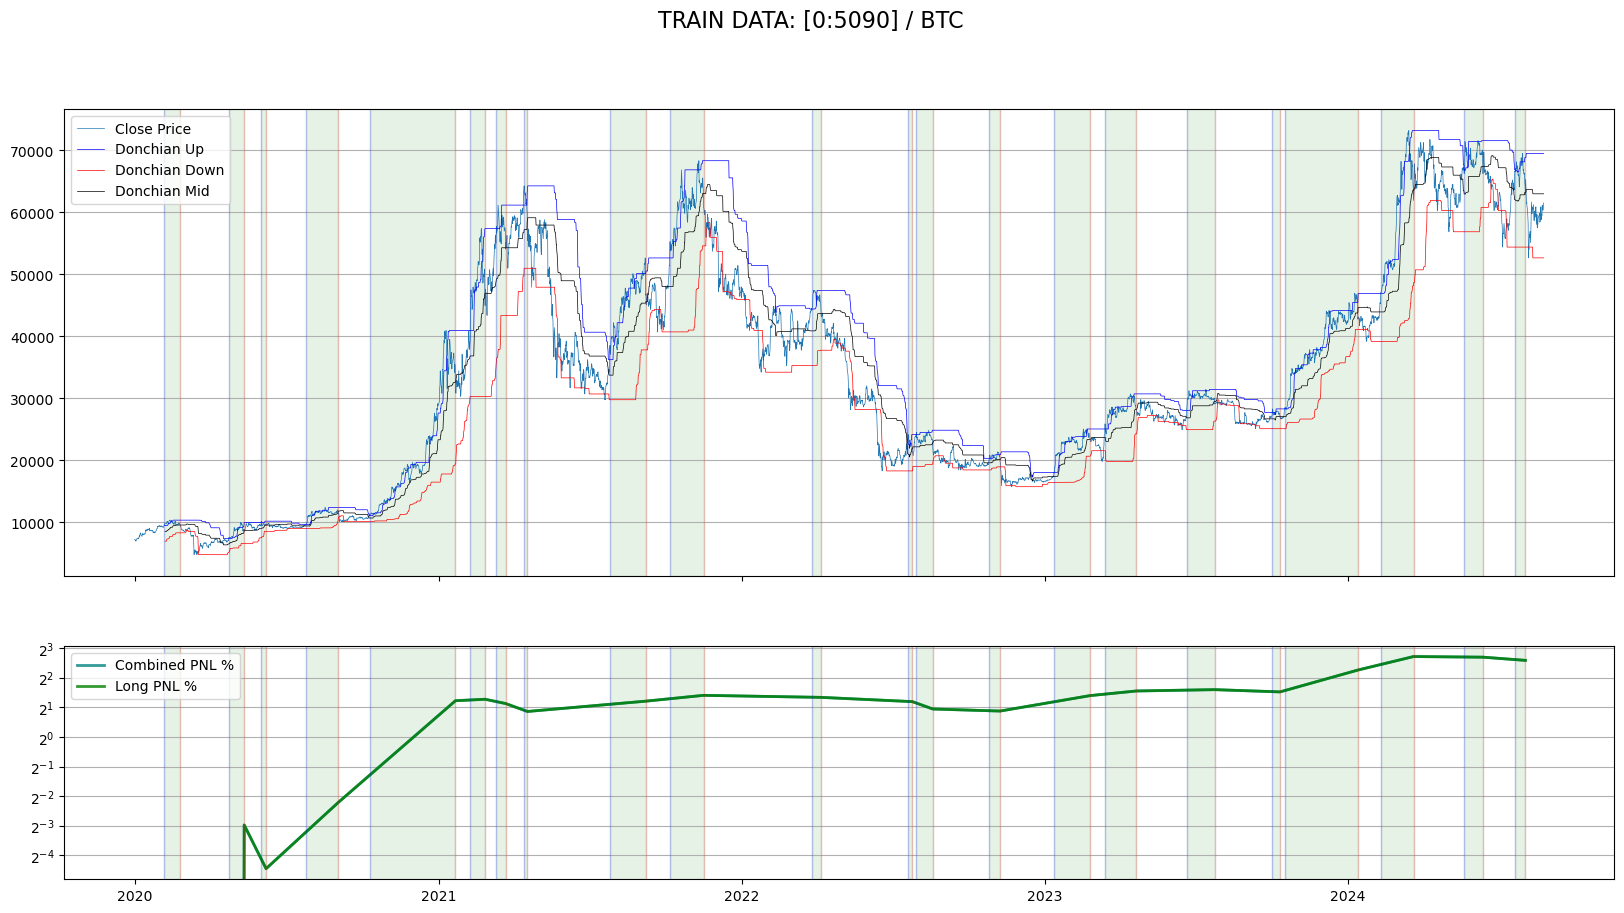

===================   BTC   =================================
params[ 1 ] = {'up_lookback': 83, 'dn_lookback': 95, 'up_lag': 13, 'dn_lag': 16, 'band_offset': 0.3867791633057942}
--- TRAIN -----------------------------------------------------
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |          5.3445 |          5.3445 |          0.0000
Max Drawdown              |         -0.3146 |         -0.3146 |          0.0000
N Trades                  |         24.0000 |         24.0000 |          0.0000
Sharpe Ratio              |          0.3210 |          0.3210 |          0.0000
Sortino Ratio             |          2.0902 |          2.0902 |          0.0000
Avg Return                |          0.0800 |          0.0800 |          0.0000
Max Win                   |          1.7465 |          1.7465 |          0.0000
Max Loss                  |         -

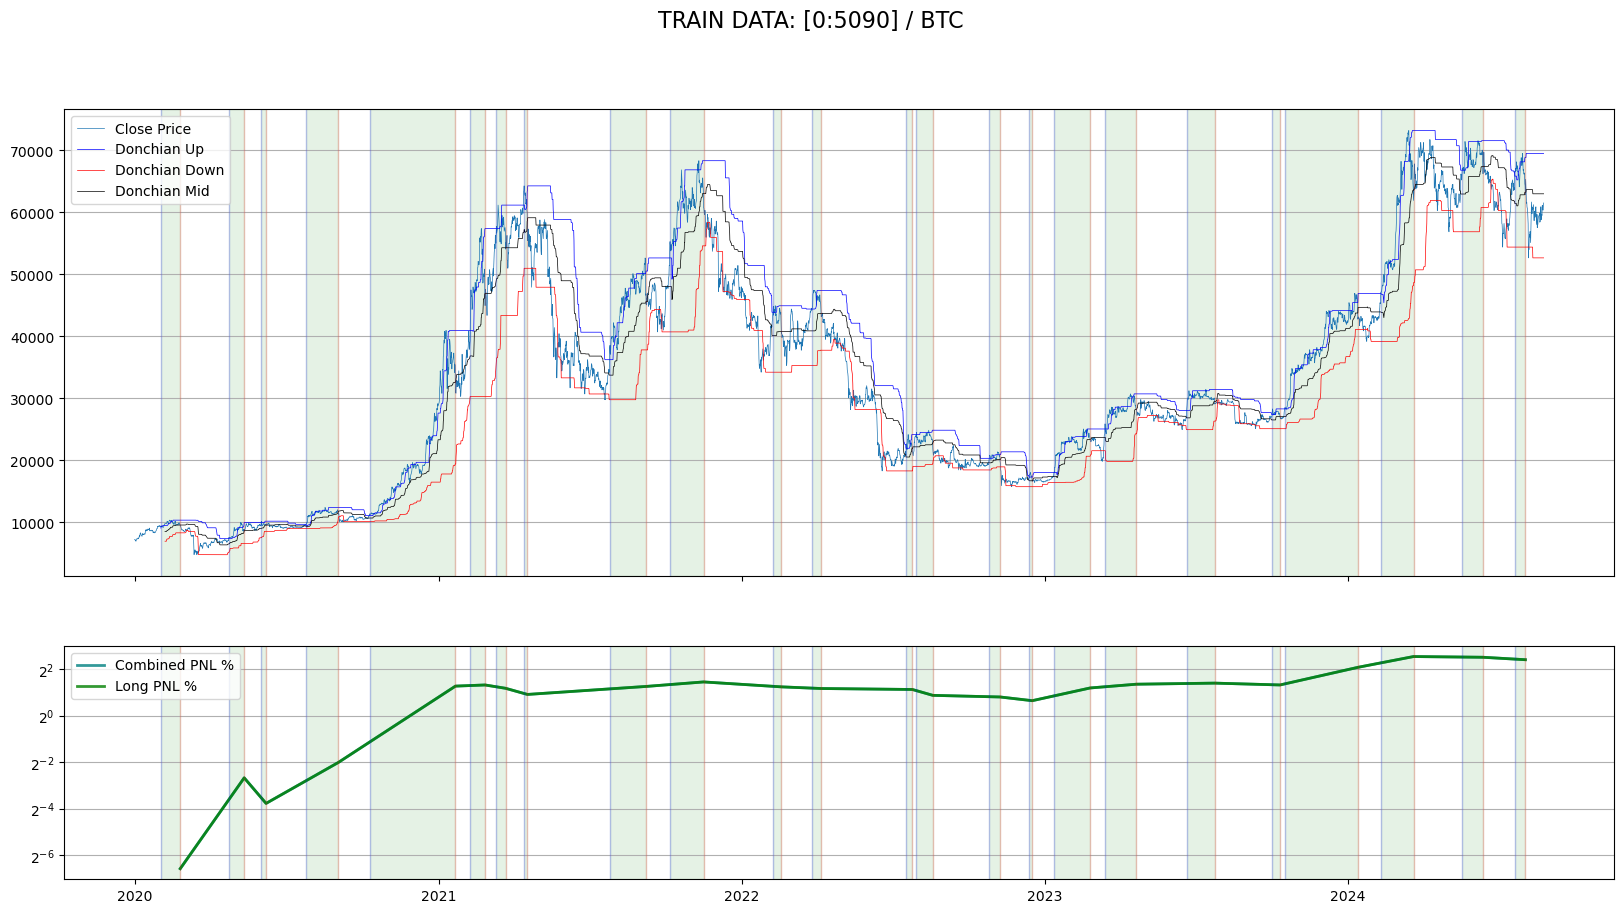

===================   BTC   =================================
params[ 2 ] = {'up_lookback': 58, 'dn_lookback': 90, 'up_lag': 19, 'dn_lag': 8, 'band_offset': 0.39900529884649205}
--- TRAIN -----------------------------------------------------
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |          6.8846 |          6.8846 |          0.0000
Max Drawdown              |         -0.2909 |         -0.2909 |          0.0000
N Trades                  |         27.0000 |         27.0000 |          0.0000
Sharpe Ratio              |          0.4455 |          0.4455 |          0.0000
Sortino Ratio             |          2.8793 |          2.8793 |          0.0000
Avg Return                |          0.0795 |          0.0795 |          0.0000
Max Win                   |          0.5588 |          0.5588 |          0.0000
Max Loss                  |         -

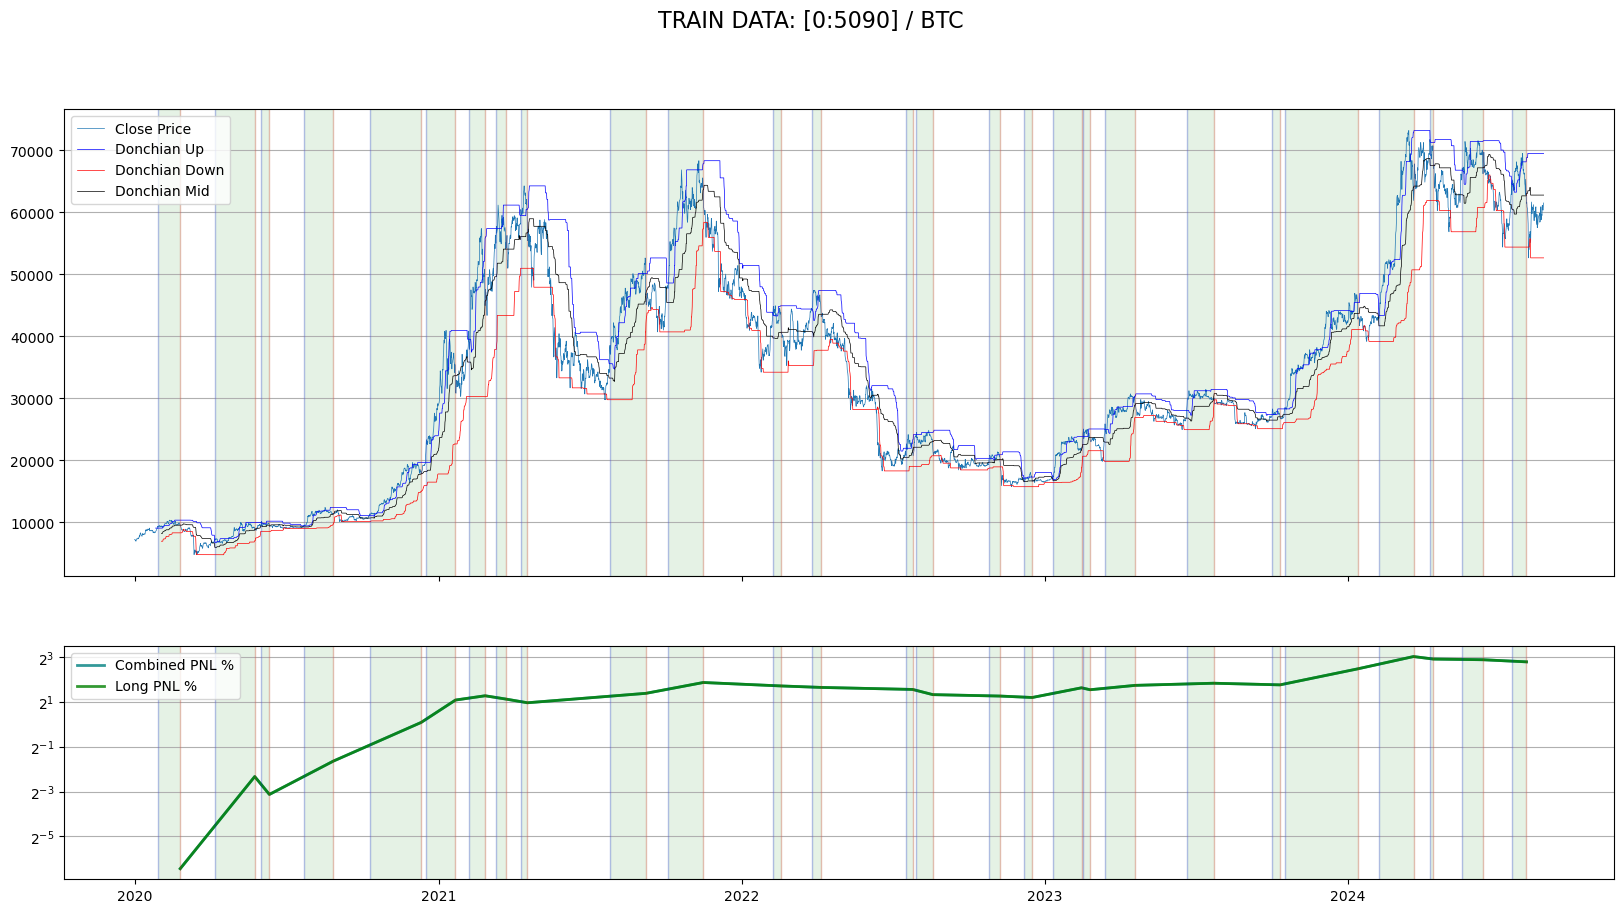

In [74]:

# Proceed with optimizing and testing as before

optuna.logging.set_verbosity(optuna.logging.ERROR)
# Load the data
# asset = 'TSLA'
# data = load_sp500_stock_candles(asset)['2010':'2025']
# data['close'] = data['adj close']
# data = load_russel2000_candles('XOXO')['2006':]
asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
data = load_candles('binance',asset, quote, timeframe)['2020':'2025']#.iloc[-35000:-5000]
nhours = 1; train_ratio = 1
# data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
data_train = data.iloc[:int(data.shape[0]*train_ratio)]; data_test = data.iloc[data_train.shape[0]:]
study = optimize(data_train, param_defs,indicators=indicators, signals=signals, enable_long=False, enable_short=True ,xmult=1, n_trials=100, optimize_metrics=['overall_metrics.tot_return', 'overall_metrics.sharpe_ratio'])
aparams = [t.params for t in reversed(study.best_trials[-10:])]
# def custom_metric(metrics):
#     return metrics['overall_metrics']['tot_return'] / abs(metrics['overall_metrics']['max_drawdown'])

# study = optimize(
#     data, 
#     nhours, 
#     param_defs, 
#     optimize_metrics=['overall_metrics.max_drawdown', 'short_metrics.profit_factor'],
#     directions=['maximize', 'maximize'],
#     n_trials=100
# )
# aparams = [t.params for t in reversed(study.best_trials[-10:])]

print(f'aparams = {aparams}')
for ipa, params in enumerate(aparams):
    print(f'===================   {asset}   =================================')
    print(f'params[ {ipa} ] = {params}')
    if len(data_train): 
        print('--- TRAIN -----------------------------------------------------')
        fig_tr,res_tr = plot_performance(data_train,asset,params, indicators=indicators, enable_short=False, signals=signals, reset_index=False, btkwargs={'xmult':1, 'slippage': 0.005, 'transaction_cost': 0.001, 'period_costs': 0.0003/6}, title=f'TRAIN DATA: [0:{data_train.shape[0]}]')
    # if len(data_test): 
        # print('--- TEST ------------------------------------------------------')
        # fig_ts, res_ts = print_performance(data_test,nhours,asset,reset_index=False,params=params,btkwargs={'short_long':[-1,1], 'xmult':1}, title=f'TEST DATA: [{data_test.shape[0]}:{data.shape[0]}]')
    


In [75]:
study.best_trials

[FrozenTrial(number=9, state=TrialState.COMPLETE, values=[2.591483161839964, 0.34371745350288657], datetime_start=datetime.datetime(2024, 8, 25, 3, 52, 50, 643155), datetime_complete=datetime.datetime(2024, 8, 25, 3, 52, 50, 647413), params={'up_lookback': 58, 'dn_lookback': 90, 'up_lag': 19, 'dn_lag': 8, 'band_offset': 0.39900529884649205}, user_attrs={}, system_attrs={'nsga2:generation': 0}, intermediate_values={}, distributions={'up_lookback': IntDistribution(high=100, log=False, low=10, step=1), 'dn_lookback': IntDistribution(high=100, log=False, low=10, step=1), 'up_lag': IntDistribution(high=20, log=False, low=5, step=1), 'dn_lag': IntDistribution(high=20, log=False, low=5, step=1), 'band_offset': FloatDistribution(high=1.0, log=False, low=0.0, step=None)}, trial_id=9, value=None),
 FrozenTrial(number=49, state=TrialState.COMPLETE, values=[2.800714227391591, 0.3155519978847509], datetime_start=datetime.datetime(2024, 8, 25, 3, 52, 50, 823733), datetime_complete=datetime.datetime(

In [ ]:
real = talib.NATR(data.high, data.low, data.close, timeperiod=14)
real.hist()

## Parameer analysis

In [ ]:
optuna.visualization.plot_param_importances(
    study, target=lambda t: t.duration.total_seconds(), target_name="duration"
)

In [ ]:
optuna.visualization.plot_pareto_front(study, target_names=["tot_return", "trade_max_drawdown"])

In [ ]:
plot_edf(study,target=lambda s: s.values[0])

In [ ]:
fig = plot_rank(study,target=lambda s: s.values[0])
plt.tight_layout()
fig


In [ ]:
plot_timeline(study)

In [ ]:
fig = plot_intermediate_values(study)

# fig.update_layout(
#     title="Hyperparameter optimization for Donchian Breakout strategy",
#     xaxis_title="Epoch",
#     yaxis_title="tot_return",
# )
fig

In [ ]:
for params in [t.params for t in study.best_trials]:
    print(f'params = {params}')
    print_performance(data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)

## Backtest a list of params on a bunch of assets

#### Load and map assets to existing data from exchanges

In [76]:
import os
btimeframe = timeframe
# btimeframe = '4h'
base_data_dir = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data"
# quote, timeframe, nhours = 'USDT', '8h', 8
exchanges = ['binance', 'kucoin', 'bybit', 'bitget']
# with open("assets-portfolio.txt", "r") as file: assets = [line.strip() for line in file.readlines()][:20]
with open("top100MarketCap.txt", "r") as file: assets = [line.strip() for line in file.readlines()][:30]
# assets = filter(lambda a: not 'USD' in a, assets)
assets = [a for a in assets if 'USD' not in a and a not in ['LUNA', 'RENDER']]
# assets
# df_pf = pd.DataFrame(assets,columns=['asset'])
dfae = pd.DataFrame([
    [(os.path.exists(f'{base_data_dir}/{exchange}/{asset}_{quote}-{btimeframe}.json')) for exchange in exchanges]
    for asset in assets
]).set_axis(exchanges, axis=1)#.set_axis(assets,axis=0)
dfae.index = assets

dfae['first_exch'] = dfae.apply(lambda row: row.idxmax() if row.any() else None, axis=1)
# assets, exchanges = 
assets, exchanges = (dfae[~dfae['first_exch'].isna()][['first_exch']].reset_index().T.values)
asset_exchange = list(dfae[~dfae['first_exch'].isna()][['first_exch']].to_records())
# asset_exchange
# list(asset_exch)



#### Backtest and collect results

In [77]:
def xtract_primitive_values(opt_bt) : 
    return {k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))}

def remove_keys_with_unwanted_values(d):
    """
    Recursively remove keys from a dictionary if their values are
    instances of list, numpy array, pandas Series, or pandas DataFrame.
    """
    if not isinstance(d, dict):
        return d

    keys_to_remove = [key for key, value in d.items() if isinstance(value, (list, np.ndarray, pd.Series, pd.DataFrame, pd.DatetimeIndex))]

    for key in keys_to_remove:
        del d[key]

    # Recursively apply the function to sub-dictionaries
    for key, value in d.items():
        if isinstance(value, dict):
            remove_keys_with_unwanted_values(value)
    
    return d

In [78]:
# quote, timeframe, nhours = 'USDT', '4h', 4
# inc_metrics = ['asset', 'ipa', 'long_metrics', 'short_metrics', 'overall_metrics', 'rsi_period', 'up_rsi_thre', 'up_lookback', 'dn_lookback', 'up_lag', 'dn_lag', 'band_offset', 'count_since_last_cross']

bt_resa = []
for asset,exchange in tqdm(asset_exchange):
    data = load_candles(exchange,asset,quote,btimeframe)['2020-12':]
    for ipa,params in enumerate(aparams):
        res = backtest(data, params, indicators=indicators, signals=signals,enable_long=True,enable_short=False)
        bt_resa.append({'exchange.exchange': exchange, 'asset.asset': asset, 'tfr.tfr': btimeframe, 'ipa.ipa': ipa, **remove_keys_with_unwanted_values(res), 'params': params})
                

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 68.66it/s]

No trades found.
No trades found.
No trades found.


In [79]:
# bt_resa[0:1]

In [80]:
from collections.abc import MutableMapping

    
def flatten_dict(d, parent_key='', sep='.'):
    items = []
    for k, v in d.items():
        new_key = f'{parent_key}{sep}{k}' if parent_key else k
        if isinstance(v, MutableMapping):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


flattened_data = [flatten_dict(item) for item in bt_resa]

df = pd.DataFrame(flattened_data)
df.columns = pd.MultiIndex.from_tuples([tuple(col.split('.')) for col in df.columns], names=['Category', 'Type'])

# df.index.set_names(['Category', 'Type'], inplace=True)

df = df.loc[:,[
 ('exchange', 'exchange'),
 ('asset', 'asset'),
 ('tfr', 'tfr'),
 ('ipa', 'ipa'),
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('overall_metrics', 'sharpe_ratio'),
 ('overall_metrics', 'sortino_ratio'),
 ('overall_metrics', 'n_trades'),
 ('overall_metrics', 'win_ratio'),
 ('long_metrics', 'tot_return'),
 ('long_metrics', 'max_drawdown'),
 ('short_metrics', 'tot_return'),
 ('short_metrics', 'max_drawdown'),
 ('params', 'up_lookback'),
 ('params', 'dn_lookback'),
 ('params', 'up_lag'),
 ('params', 'dn_lag'),
 ('params', 'band_offset')]]

df.loc[:,[
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('long_metrics', 'tot_return'),
 ('long_metrics', 'max_drawdown'),
 ('short_metrics', 'tot_return'),
 ('short_metrics', 'max_drawdown')]] = df.loc[:,[
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('long_metrics', 'tot_return'),
 ('long_metrics', 'max_drawdown'),
 ('short_metrics', 'tot_return'),
 ('short_metrics', 'max_drawdown')]].apply(np.expm1).round(2)
 
df.to_csv(f'asset_donch_backtest--{btimeframe}.csv', index=False)
# df.columns
# df = df[(df[('overall_metrics', 'sortino_ratio')] > 0.6) & (df[('overall_metrics', 'tot_return')] > 3)]
# df = df[(df[('overall_metrics', 'max_drawdown')] > -0.5) & (df[('overall_metrics', 'tot_return')] > 10)]
print(f'aparams={aparams}')
df = df[[
 ('exchange', 'exchange'),
 ('asset', 'asset'),
 ('tfr', 'tfr'),
 ('ipa', 'ipa'),
 ('overall_metrics', 'tot_return'),
 ('overall_metrics', 'max_drawdown'),
 ('overall_metrics', 'sharpe_ratio'),
 ('overall_metrics', 'sortino_ratio'),
 ('overall_metrics', 'n_trades'),
 ('overall_metrics', 'win_ratio'),
 ('params', 'up_lookback'),
 ('params', 'dn_lookback'),
 ('params', 'up_lag'),
 ('params', 'dn_lag'),
 ('params', 'band_offset')]].droplevel(0, axis=1)
# df
# df.sort_values(('tot_return'))#.head(50)
# df = df.loc[df.groupby(['asset'])['tot_return'].idxmax()]
# df.groupby('asset', axis=1).apply(
#     lambda x: x.loc[x[ ('tot_return')].idxmax()])
df = df[df['tot_return'] < 300]
print(f'length: {df.shape[0]}')
df

aparams=[{'up_lookback': 96, 'dn_lookback': 95, 'up_lag': 13, 'dn_lag': 16, 'band_offset': 0.3867791633057942}, {'up_lookback': 83, 'dn_lookback': 95, 'up_lag': 13, 'dn_lag': 16, 'band_offset': 0.3867791633057942}, {'up_lookback': 58, 'dn_lookback': 90, 'up_lag': 19, 'dn_lag': 8, 'band_offset': 0.39900529884649205}]
length: 74


Type,exchange,asset,tfr,ipa,tot_return,max_drawdown,sharpe_ratio,sortino_ratio,n_trades,win_ratio,up_lookback,dn_lookback,up_lag,dn_lag,band_offset
0,binance,BTC,8h,0,0.90,-0.22,0.239409,0.928857,18.0,0.444444,96,95,13,16,0.386779
1,binance,BTC,8h,1,0.97,-0.31,0.240632,0.883141,20.0,0.450000,83,95,13,16,0.386779
2,binance,BTC,8h,2,2.09,-0.29,0.341036,1.883571,22.0,0.409091,58,90,19,8,0.399005
3,binance,ETH,8h,0,1.82,-0.19,0.348078,0.841629,20.0,0.500000,96,95,13,16,0.386779
4,binance,ETH,8h,1,3.95,-0.19,0.379369,1.281766,21.0,0.523810,83,95,13,16,0.386779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,binance,NEAR,8h,1,25.17,-0.19,0.492330,2.631491,18.0,0.666667,83,95,13,16,0.386779
74,binance,NEAR,8h,2,20.41,-0.37,0.358412,1.568592,21.0,0.523810,58,90,19,8,0.399005
75,binance,XLM,8h,0,-0.59,-0.68,-0.391917,-0.700456,22.0,0.318182,96,95,13,16,0.386779
76,binance,XLM,8h,1,-0.52,-0.62,-0.308487,-0.517336,23.0,0.347826,83,95,13,16,0.386779


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

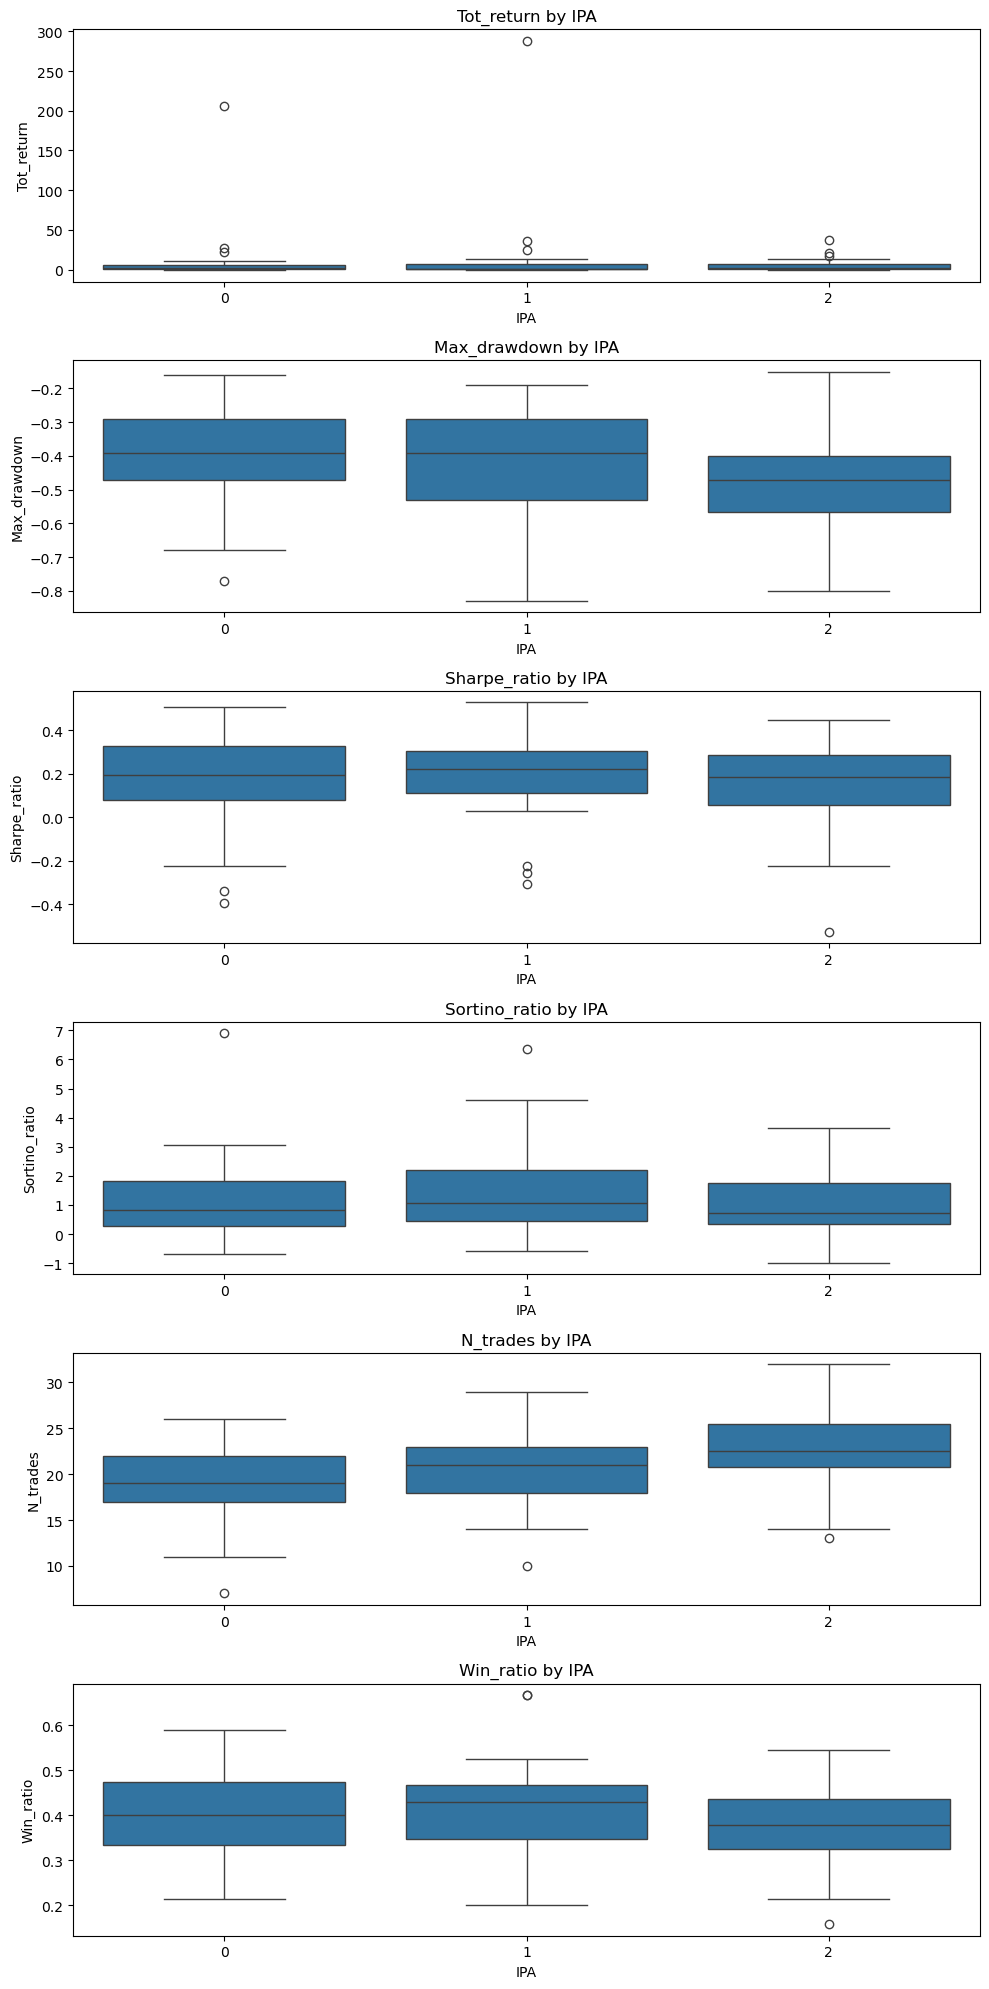

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics to plot
metrics_to_plot = ['tot_return', 'max_drawdown', 'sharpe_ratio', 'sortino_ratio', 'n_trades', 'win_ratio']

# Set up the matplotlib figure
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 20))

# Generate a box plot for each metric grouped by 'ipa'
for i, metric in enumerate(metrics_to_plot):
    sns.boxplot(x='ipa', y=metric, data=df, ax=axes[i])
    axes[i].set_title(f'{metric.capitalize()} by IPA')
    axes[i].set_xlabel('IPA')
    axes[i].set_ylabel(metric.capitalize())

plt.tight_layout()
plt.show()


=========  ALGO  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         14.6395 |          0.2664 |         11.3491
Max Drawdown              |         -0.7205 |         -0.4719 |         -0.4837
N Trades                  |         56.0000 |         37.0000 |         19.0000
Sharpe Ratio              |          0.2045 |          0.0348 |          0.4232
Sortino Ratio             |          0.6038 |          0.1390 |          0.8868
Avg Return                |          0.0503 |          0.0064 |          0.1414
Max Win                   |          1.2253 |          1.1174 |          1.2253
Max Loss                  |         -0.3736 |         -0.1945 |         -0.3736
Avg Win                   |          0.2985 |          0.2471 |          0.3475
Avg Loss                  |         -0.0940 |         -0.

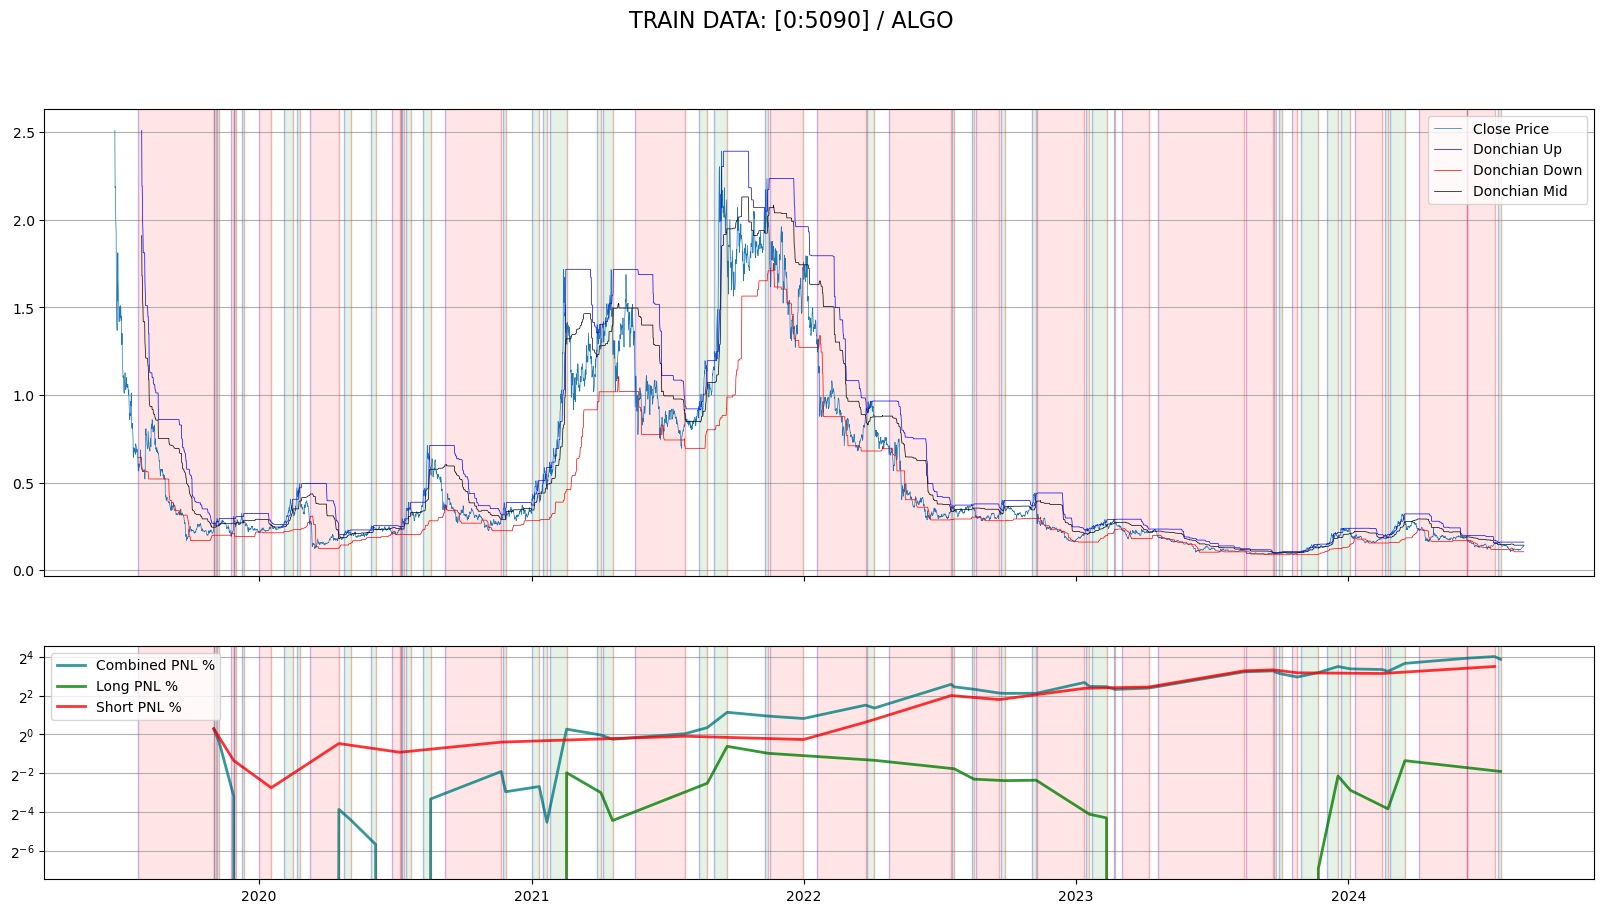

=========  AXS  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         23.4774 |          3.4341 |          4.5203
Max Drawdown              |         -0.6408 |         -0.6408 |         -0.3940
N Trades                  |         39.0000 |         26.0000 |         13.0000
Sharpe Ratio              |          0.2209 |          0.1642 |          0.3105
Sortino Ratio             |          0.5717 |          0.5701 |          0.6117
Avg Return                |          0.0854 |          0.0590 |          0.1404
Max Win                   |          2.4001 |          2.4001 |          1.7228
Max Loss                  |         -0.3940 |         -0.3503 |         -0.3940
Avg Win                   |          0.4665 |          0.5618 |          0.3867
Avg Loss                  |         -0.1397 |         -0.1

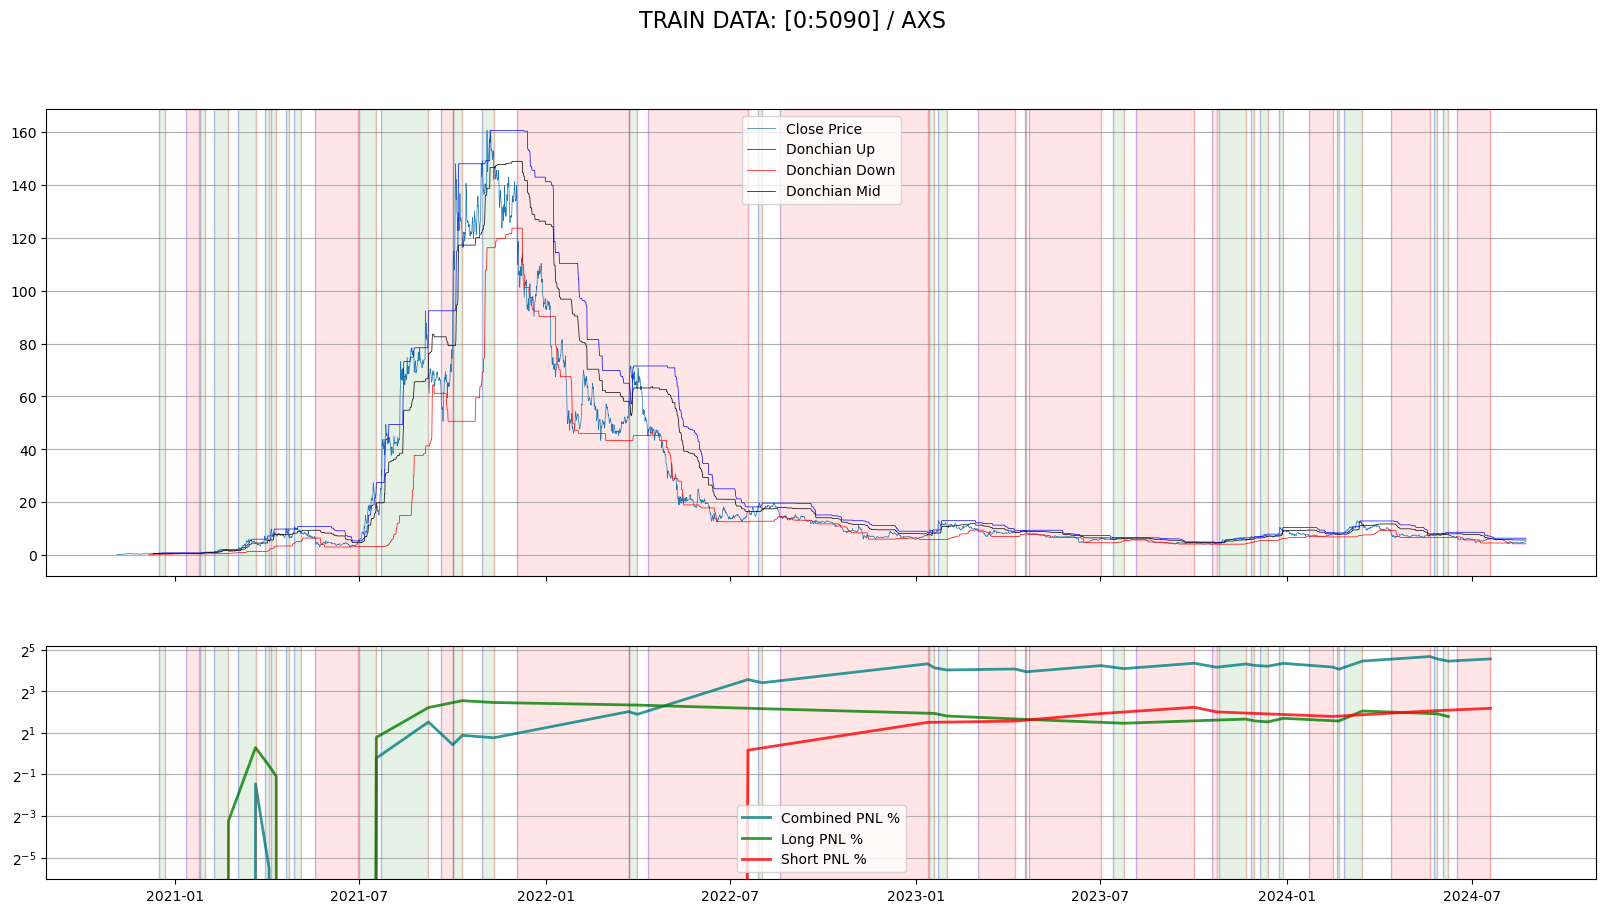

=========  BNB  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         35.6357 |         20.5346 |          0.7012
Max Drawdown              |         -0.6974 |         -0.6113 |         -0.4214
N Trades                  |         73.0000 |         48.0000 |         25.0000
Sharpe Ratio              |          0.1801 |          0.2104 |          0.1027
Sortino Ratio             |          0.7167 |          0.9273 |          0.3474
Avg Return                |          0.0506 |          0.0660 |          0.0215
Max Win                   |          3.7742 |          3.7742 |          0.5909
Max Loss                  |         -0.3009 |         -0.3009 |         -0.2162
Avg Win                   |          0.2908 |          0.3194 |          0.2403
Avg Loss                  |         -0.0976 |         -0.0

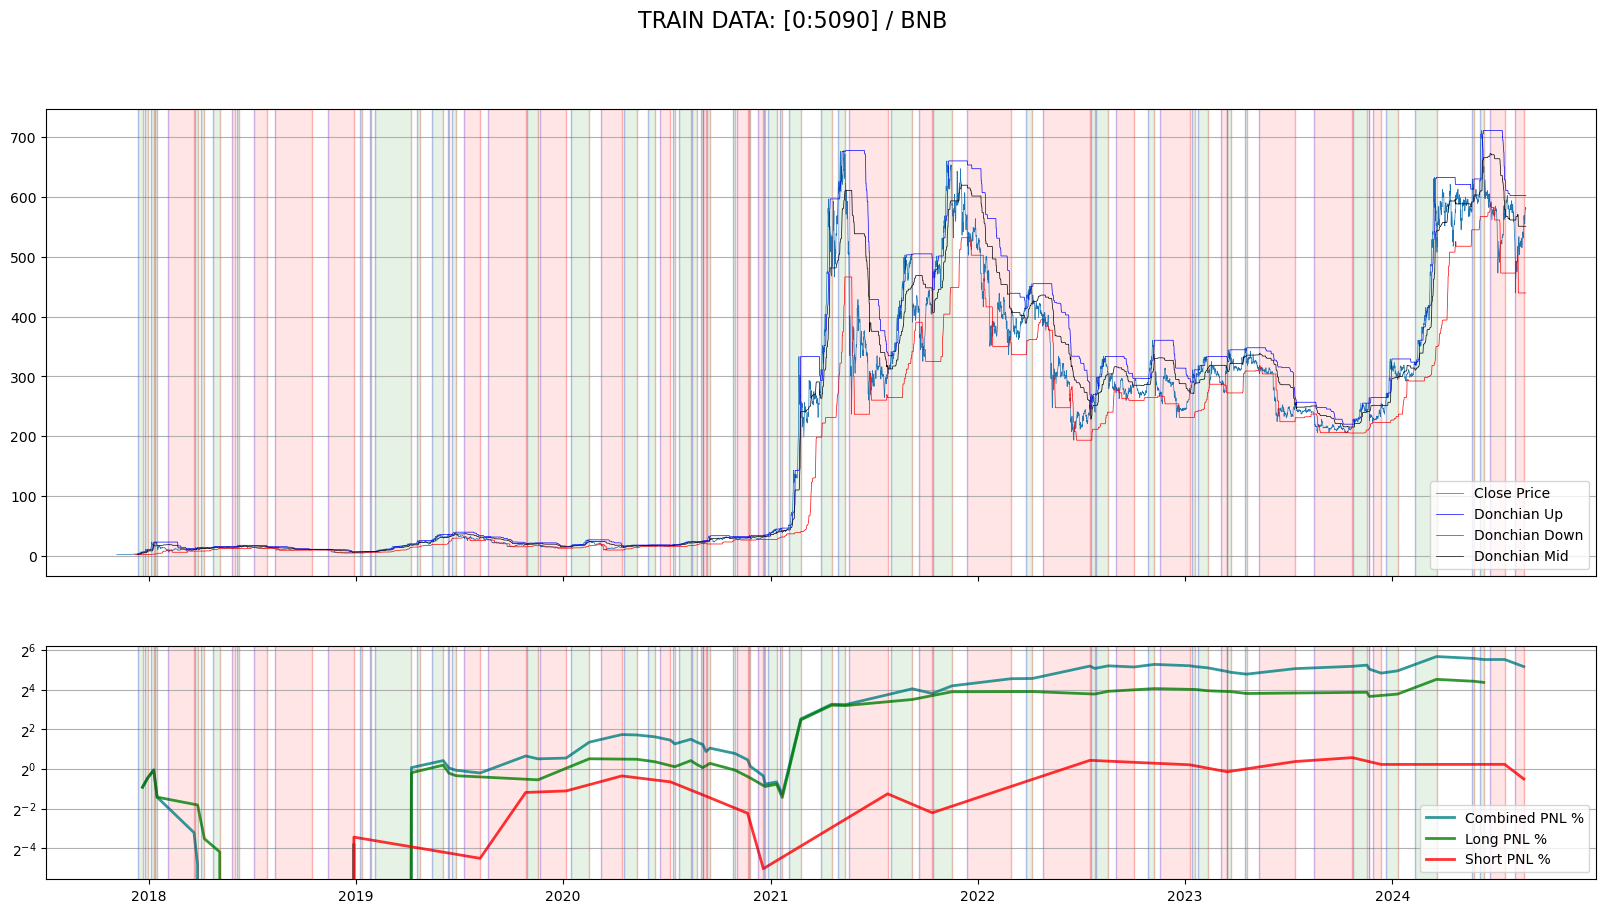

=========  BTT  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |      84347.0264 |         12.3895 |       6298.5818
Max Drawdown              |         -0.4408 |         -0.4206 |         -0.2406
N Trades                  |         46.0000 |         27.0000 |         19.0000
Sharpe Ratio              |          0.2265 |          0.2666 |          0.2806
Sortino Ratio             |          2.8548 |          1.3169 |          4.5605
Avg Return                |          0.2796 |          0.1009 |          0.5848
Max Win                   |       1260.8504 |          3.2510 |       1260.8504
Max Loss                  |         -0.2612 |         -0.2590 |         -0.2612
Avg Win                   |          0.8628 |          0.3684 |          1.6972
Avg Loss                  |         -0.0930 |         -0.0

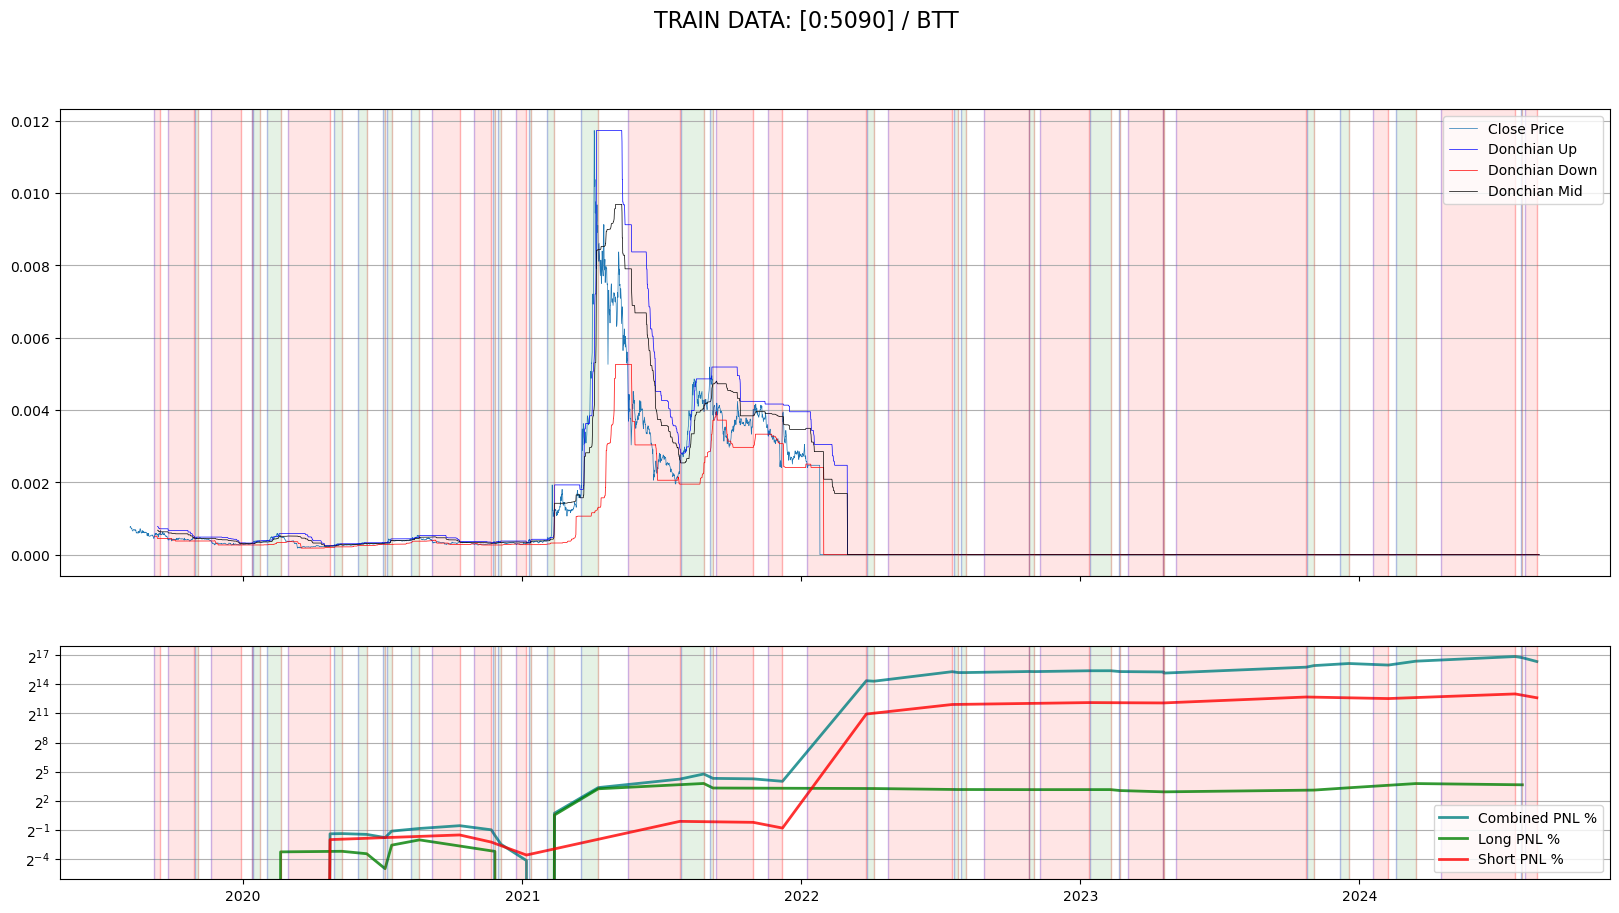

=========  CRO  /  0  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         44.6499 |          4.2996 |          7.6138
Max Drawdown              |         -0.3670 |         -0.3916 |         -0.2541
N Trades                  |         39.0000 |         24.0000 |         15.0000
Sharpe Ratio              |          0.3000 |          0.2081 |          0.4477
Sortino Ratio             |          1.5741 |          1.2915 |          1.6646
Avg Return                |          0.1029 |          0.0720 |          0.1544
Max Win                   |          2.5472 |          2.5472 |          1.9572
Max Loss                  |         -0.2024 |         -0.1781 |         -0.2024
Avg Win                   |          0.4457 |          0.6866 |          0.3180
Avg Loss                  |         -0.0863 |         -0.0

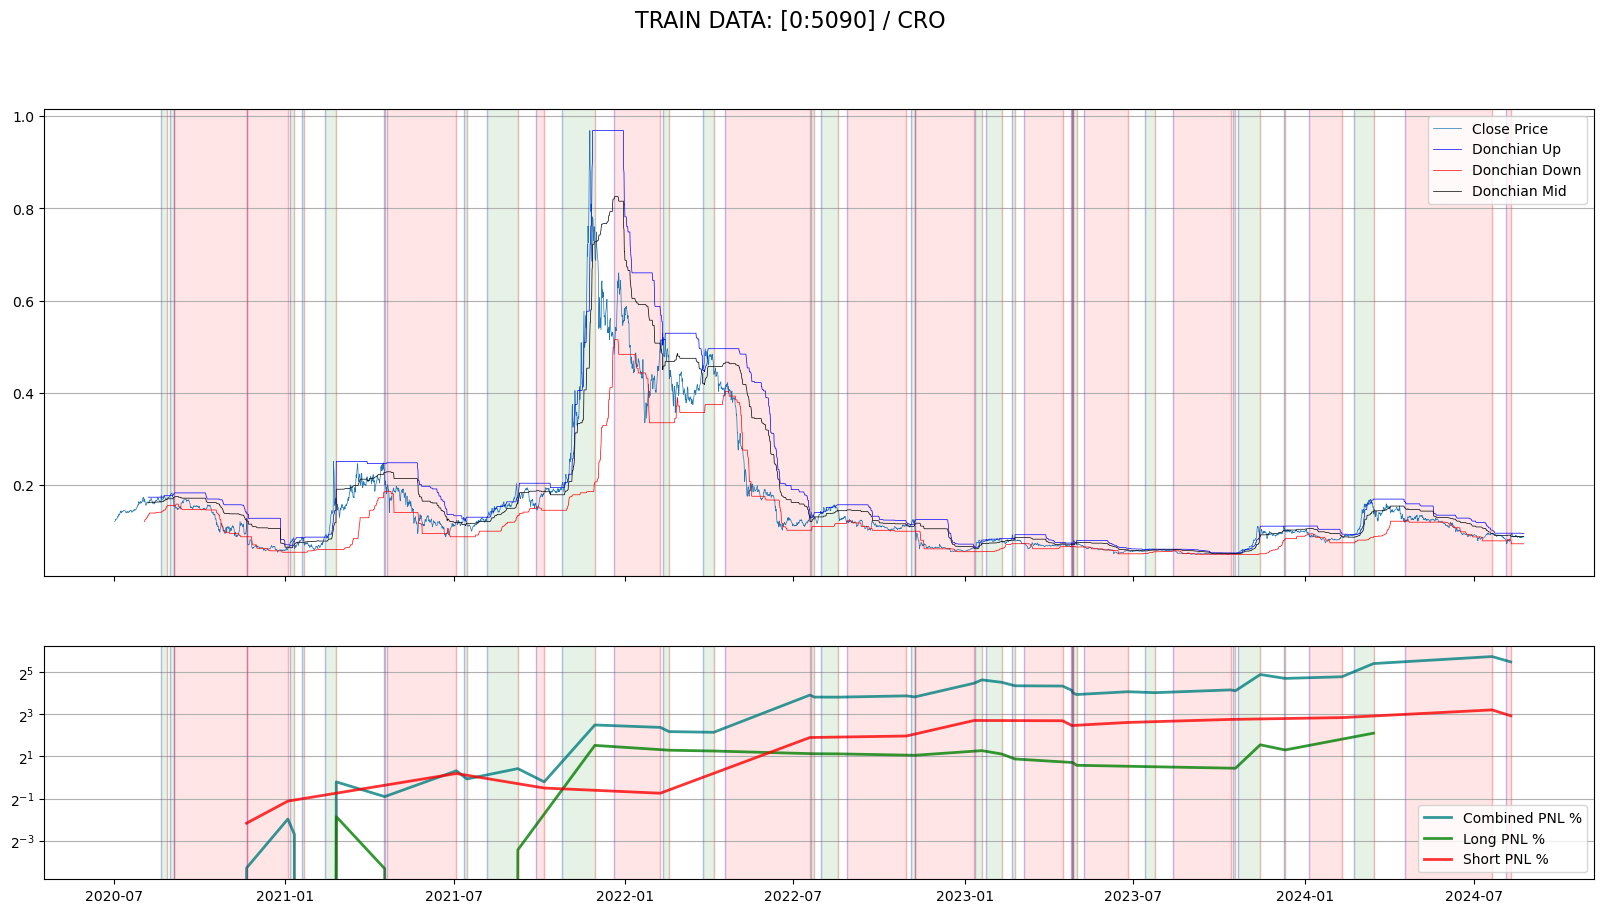

=========  DOGE  /  0  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         32.7889 |         20.4685 |          0.5739
Max Drawdown              |         -0.4995 |         -0.4872 |         -0.2334
N Trades                  |         56.0000 |         35.0000 |         21.0000
Sharpe Ratio              |          0.2404 |          0.2847 |          0.1390
Sortino Ratio             |          0.9623 |          1.6941 |          0.2464
Avg Return                |          0.0649 |          0.0916 |          0.0218
Max Win                   |          3.1104 |          3.1104 |          0.5696
Max Loss                  |         -0.2334 |         -0.1816 |         -0.2334
Avg Win                   |          0.2388 |          0.3299 |          0.1269
Avg Loss                  |         -0.0846 |         -0.

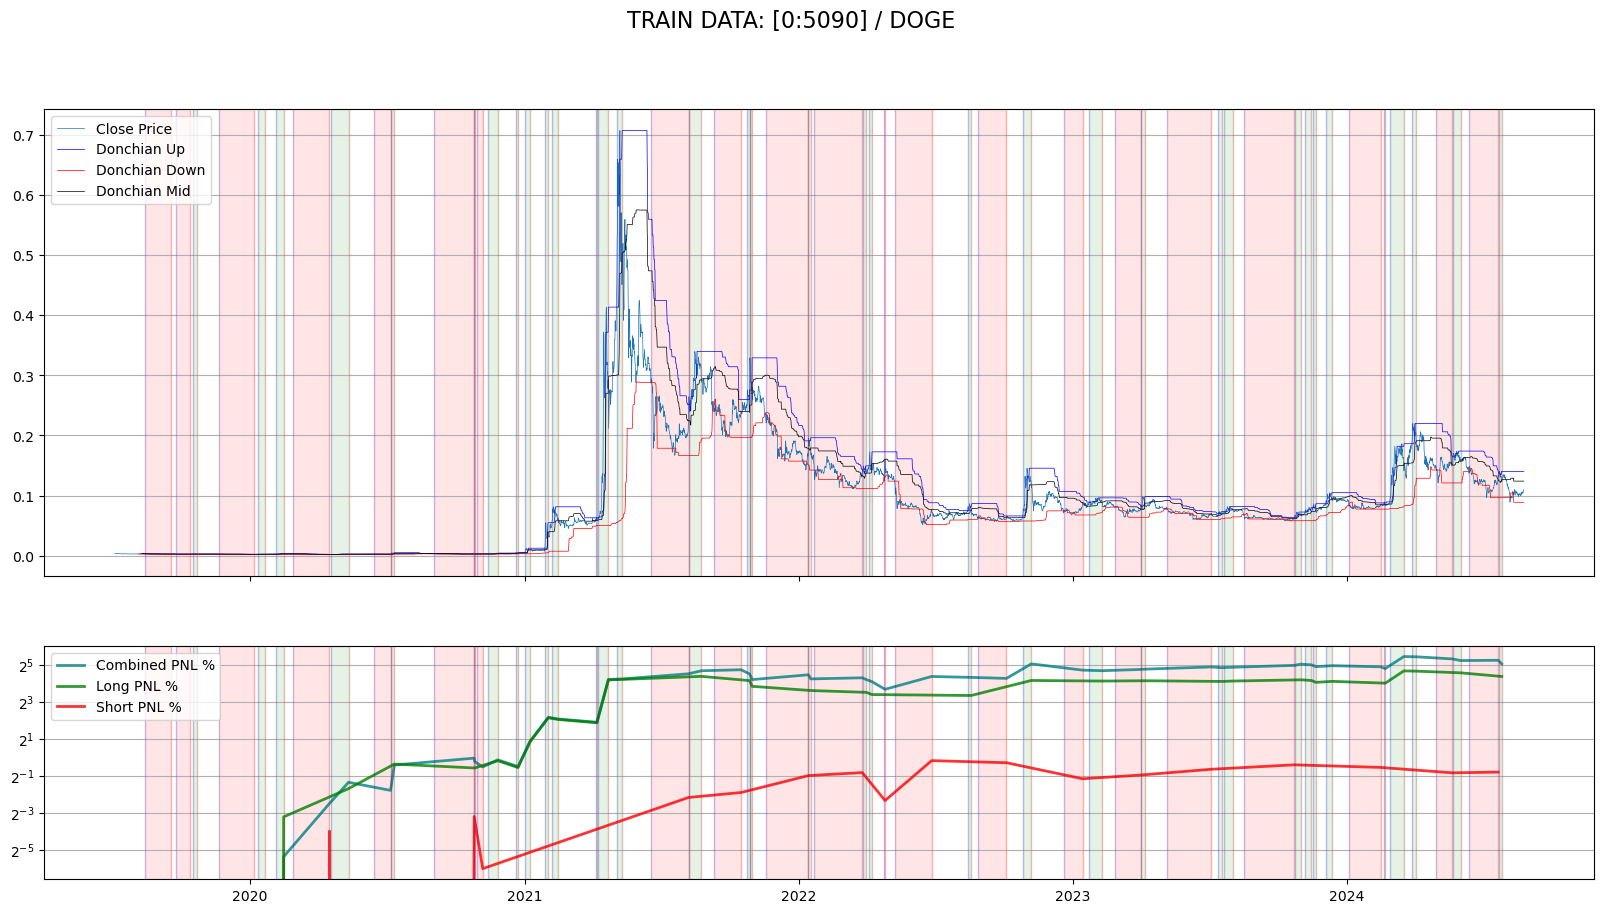

=========  DOT  /  3  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         18.4101 |          1.6377 |          6.3588
Max Drawdown              |         -0.4786 |         -0.2626 |         -0.2930
N Trades                  |         38.0000 |         25.0000 |         13.0000
Sharpe Ratio              |          0.2763 |          0.1618 |          0.4402
Sortino Ratio             |          0.9917 |          0.8475 |          1.2089
Avg Return                |          0.0812 |          0.0396 |          0.1659
Max Win                   |          1.8414 |          1.8414 |          1.1795
Max Loss                  |         -0.2930 |         -0.1457 |         -0.2930
Avg Win                   |          0.3293 |          0.3031 |          0.3531
Avg Loss                  |         -0.0854 |         -0.0

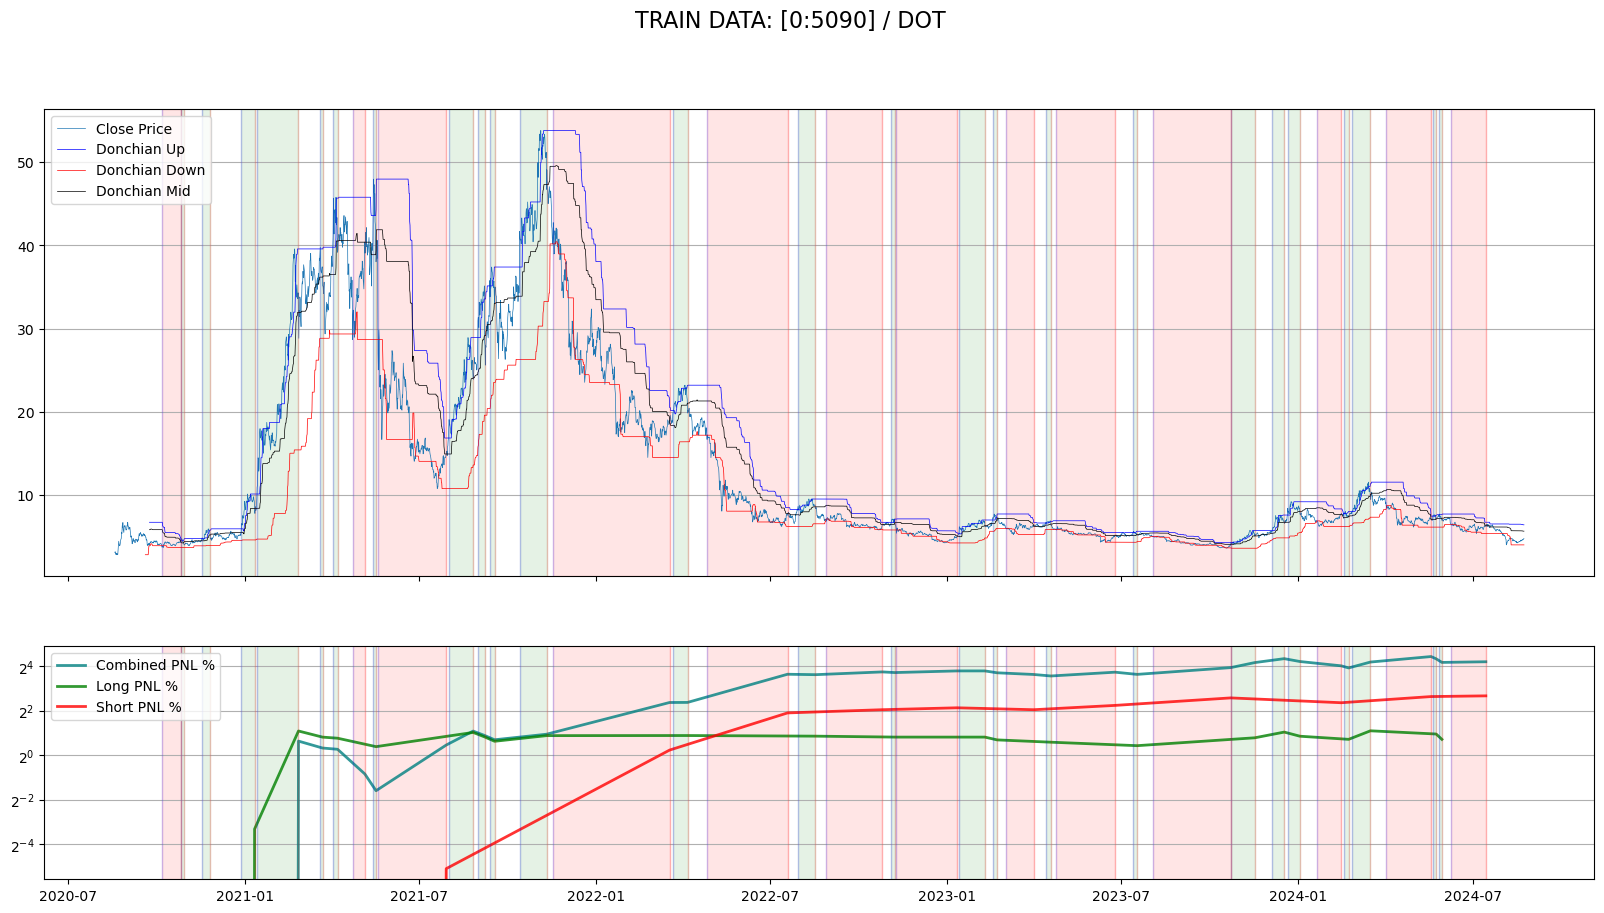

=========  EGLD  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         31.1450 |          6.8367 |          3.1019
Max Drawdown              |         -0.3913 |         -0.3483 |         -0.2674
N Trades                  |         40.0000 |         25.0000 |         15.0000
Sharpe Ratio              |          0.3016 |          0.2899 |          0.3100
Sortino Ratio             |          1.2765 |          1.8100 |          0.9859
Avg Return                |          0.0906 |          0.0858 |          0.0987
Max Win                   |          1.9642 |          1.9642 |          1.5178
Max Loss                  |         -0.2555 |         -0.1596 |         -0.2555
Avg Win                   |          0.4370 |          0.4773 |          0.3924
Avg Loss                  |         -0.0757 |         -0.

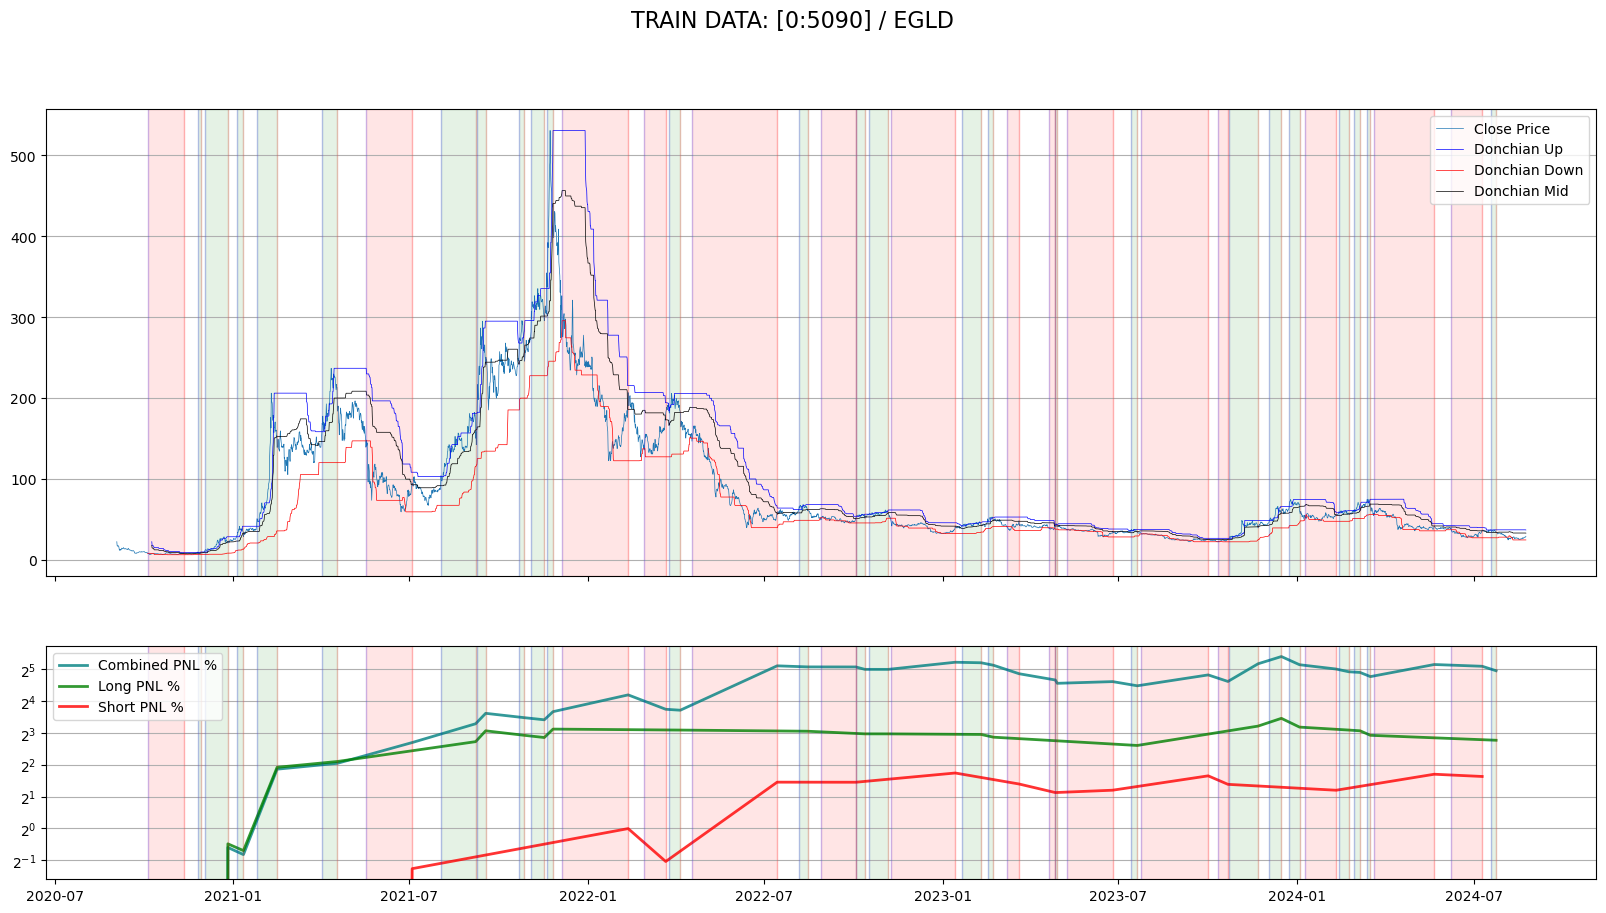

=========  FIL  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        436.0276 |         10.3483 |         37.5104
Max Drawdown              |         -0.1665 |         -0.1345 |         -0.1665
N Trades                  |         25.0000 |         14.0000 |         11.0000
Sharpe Ratio              |          0.6091 |          0.4809 |          0.7460
Sortino Ratio             |          3.7108 |          3.2073 |          2.7431
Avg Return                |          0.2753 |          0.1895 |          0.3936
Max Win                   |          2.5841 |          2.5841 |          1.9830
Max Loss                  |         -0.1665 |         -0.1345 |         -0.1665
Avg Win                   |          0.4843 |          0.4316 |          0.5328
Avg Loss                  |         -0.0762 |         -0.0

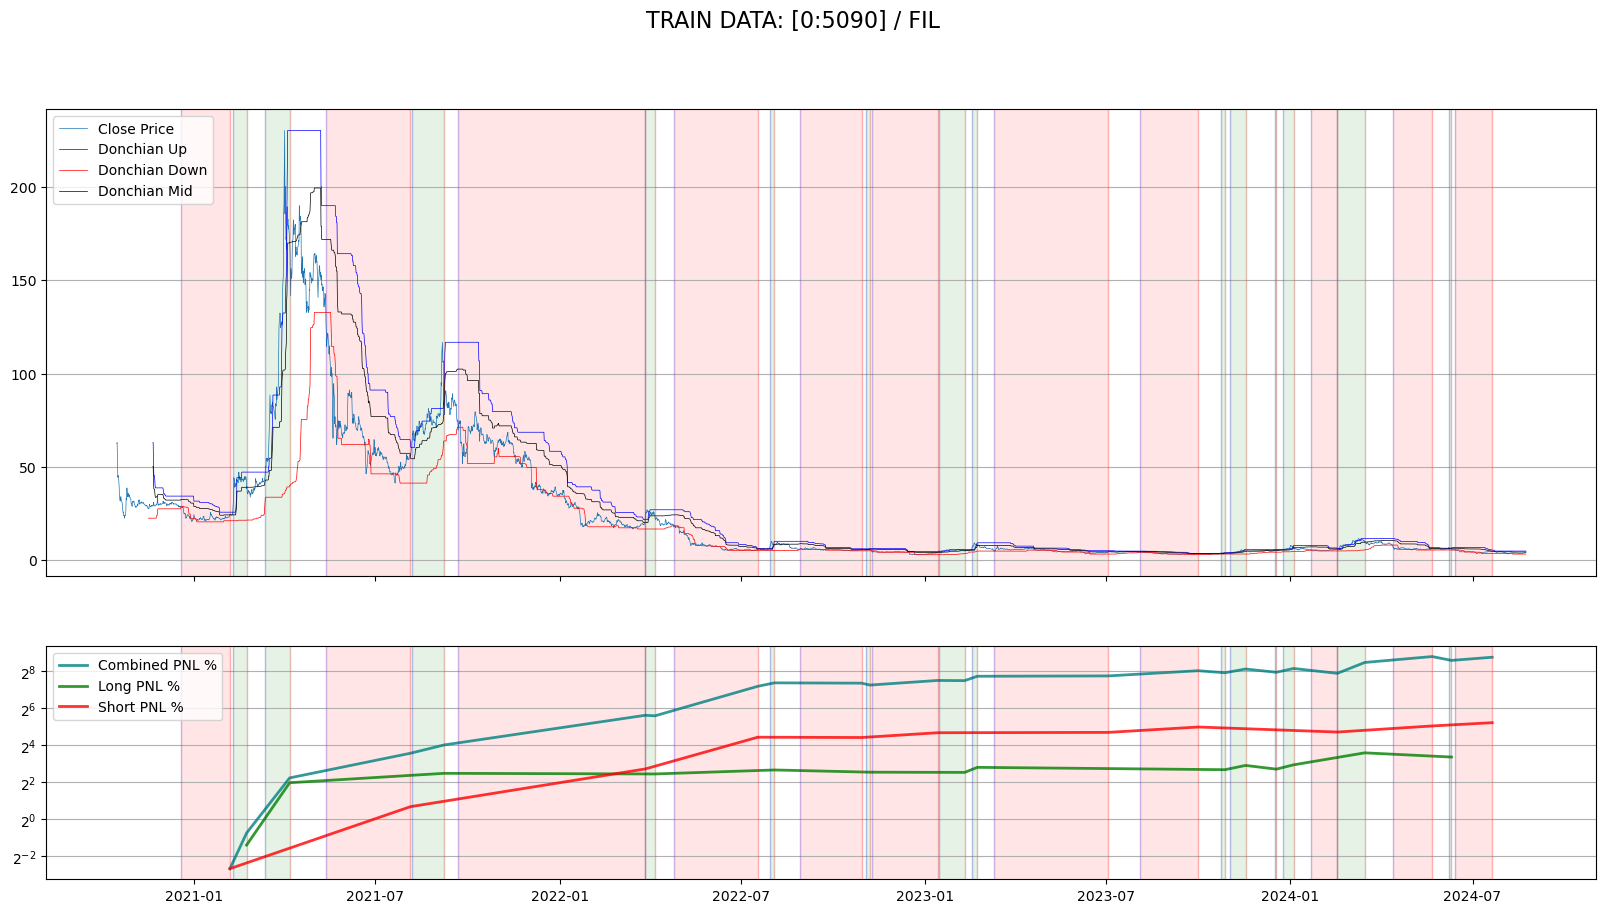

=========  FLOW  /  3  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         21.6549 |          0.5002 |         14.1012
Max Drawdown              |         -0.1520 |         -0.1596 |         -0.1352
N Trades                  |         24.0000 |         13.0000 |         11.0000
Sharpe Ratio              |          0.4891 |          0.2215 |          0.7407
Sortino Ratio             |          2.8642 |          0.7819 |          4.1653
Avg Return                |          0.1388 |          0.0317 |          0.2799
Max Win                   |          2.0533 |          0.4800 |          2.0533
Max Loss                  |         -0.1352 |         -0.1125 |         -0.1352
Avg Win                   |          0.2817 |          0.1428 |          0.3835
Avg Loss                  |         -0.0647 |         -0.

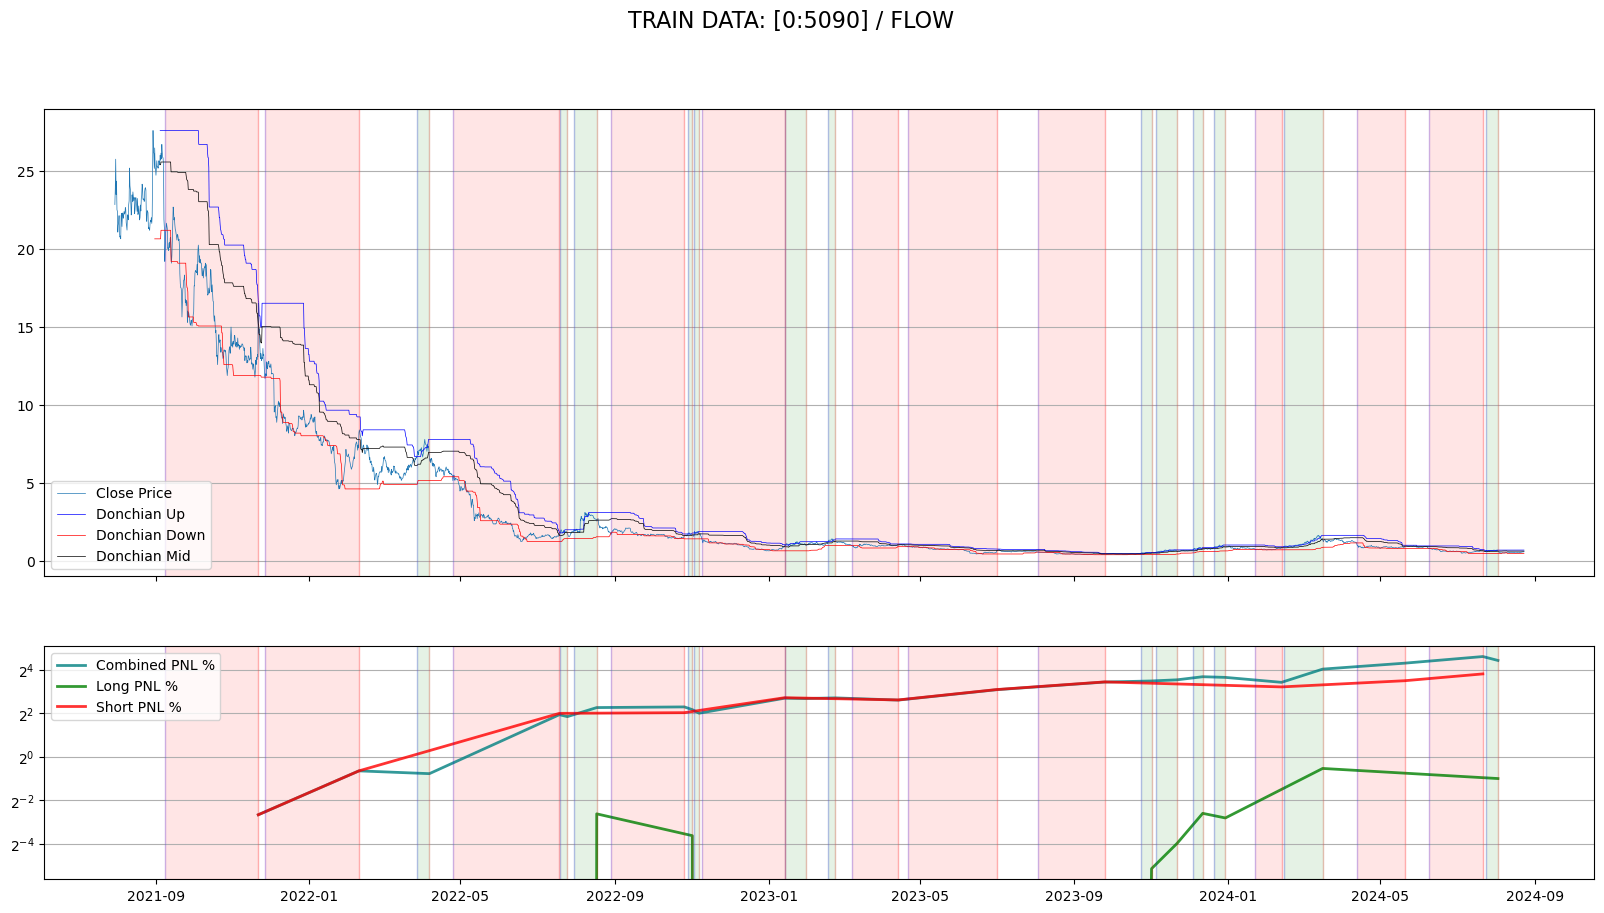

=========  GALA  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         89.2151 |         12.7414 |          5.5652
Max Drawdown              |         -0.2061 |         -0.2101 |         -0.1370
N Trades                  |         21.0000 |         11.0000 |         10.0000
Sharpe Ratio              |          0.4631 |          0.4497 |          0.4661
Sortino Ratio             |          2.4626 |          6.2310 |          1.2696
Avg Return                |          0.2391 |          0.2690 |          0.2070
Max Win                   |          3.8370 |          3.8370 |          2.1400
Max Loss                  |         -0.2661 |         -0.1248 |         -0.2661
Avg Win                   |          0.5816 |          0.8774 |          0.3993
Avg Loss                  |         -0.1051 |         -0.

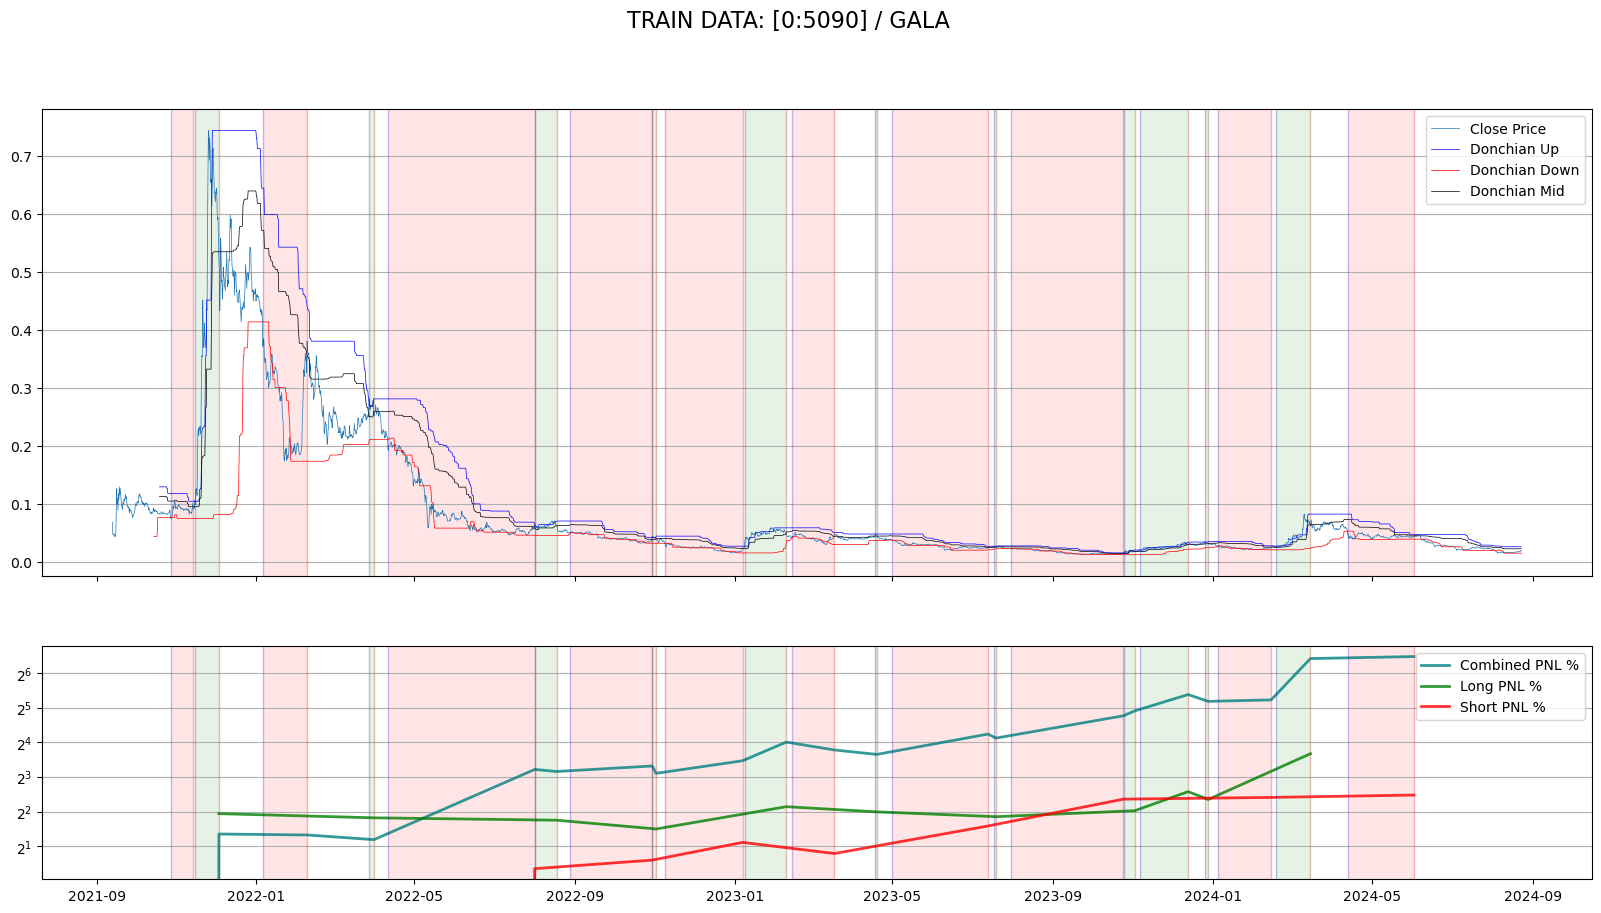

=========  GRT  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         22.6566 |          3.1187 |          4.7437
Max Drawdown              |         -0.4626 |         -0.4559 |         -0.4139
N Trades                  |         34.0000 |         19.0000 |         15.0000
Sharpe Ratio              |          0.2705 |          0.2460 |          0.2914
Sortino Ratio             |          1.1076 |          1.1038 |          1.5816
Avg Return                |          0.0975 |          0.0773 |          0.1236
Max Win                   |          2.2680 |          1.4034 |          2.2680
Max Loss                  |         -0.2682 |         -0.1911 |         -0.2682
Avg Win                   |          0.4030 |          0.4303 |          0.3822
Avg Loss                  |         -0.1177 |         -0.0

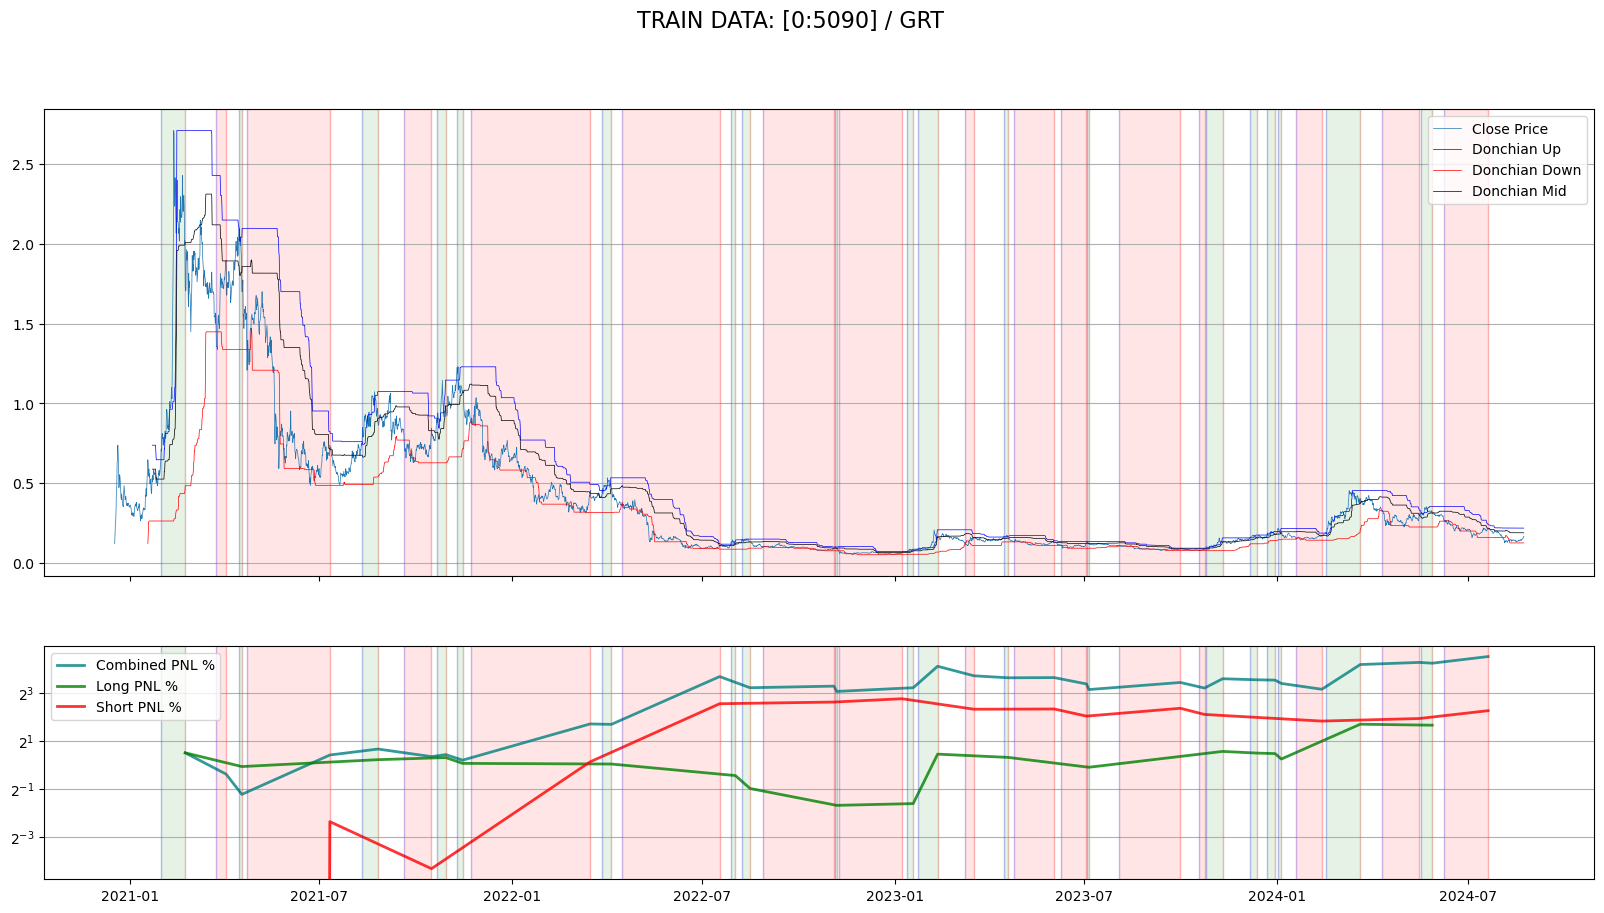

=========  HNT  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         15.4785 |          1.3440 |          6.0299
Max Drawdown              |         -0.3003 |         -0.2854 |         -0.1884
N Trades                  |         25.0000 |         15.0000 |         10.0000
Sharpe Ratio              |          0.3693 |          0.2031 |          0.5848
Sortino Ratio             |          1.9060 |          1.3527 |          2.4562
Avg Return                |          0.1186 |          0.0584 |          0.2153
Max Win                   |          1.7231 |          1.7231 |          1.1631
Max Loss                  |         -0.1884 |         -0.1254 |         -0.1884
Avg Win                   |          0.3258 |          0.2461 |          0.4105
Avg Loss                  |         -0.0989 |         -0.0

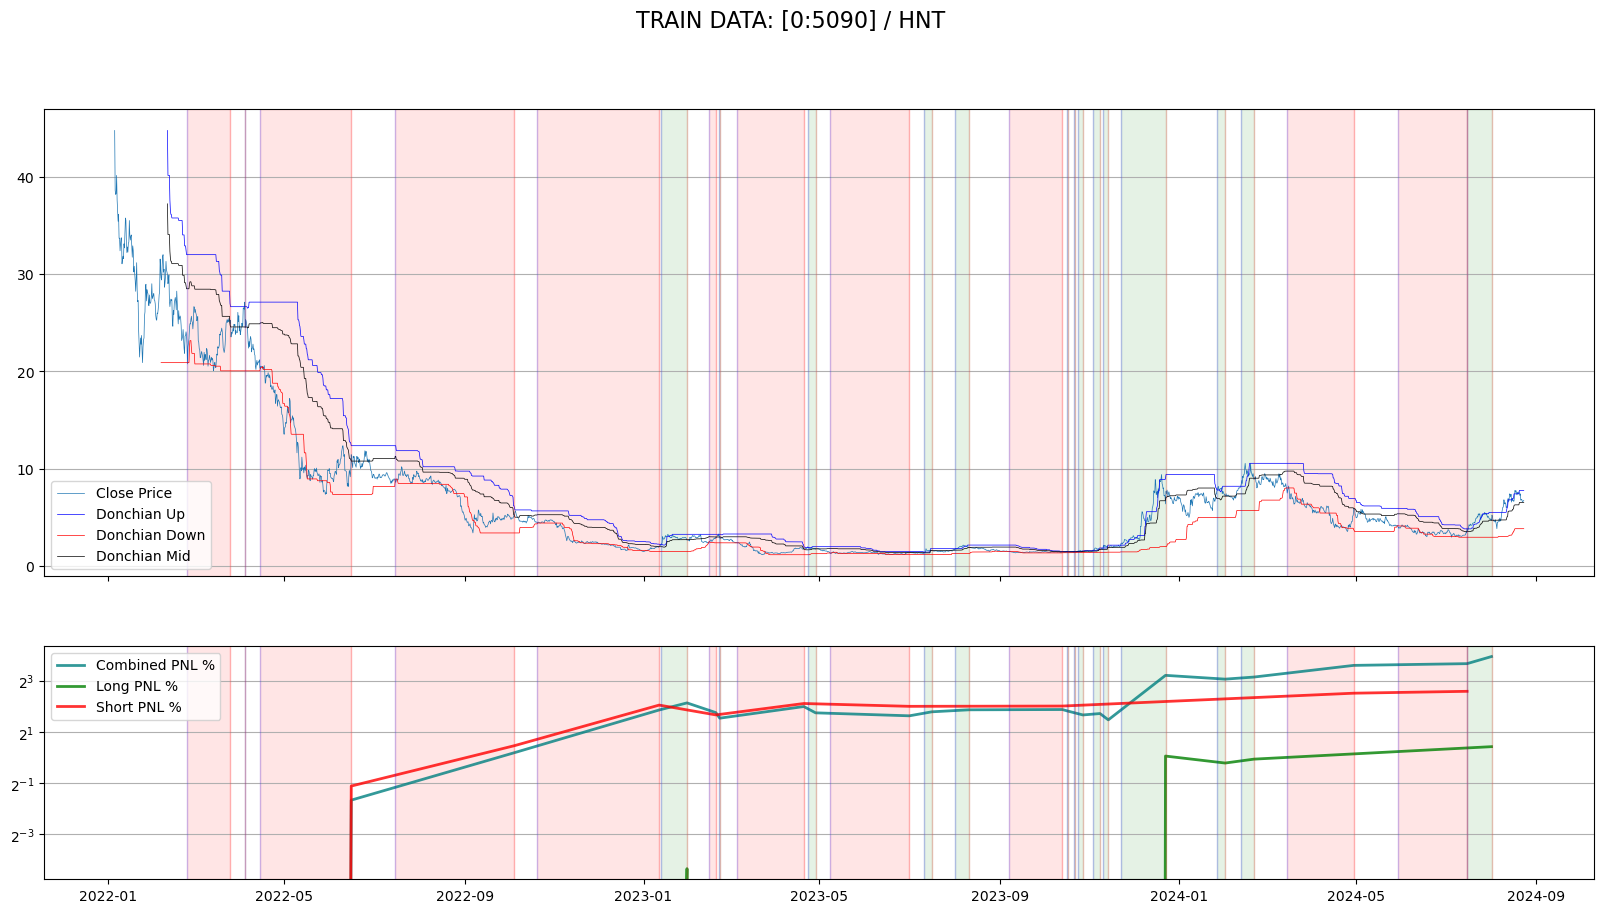

=========  ICP  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |          7.4491 |          0.2422 |          5.8019
Max Drawdown              |         -0.3610 |         -0.4062 |         -0.1946
N Trades                  |         27.0000 |         16.0000 |         11.0000
Sharpe Ratio              |          0.3241 |          0.0691 |          0.6160
Sortino Ratio             |          1.0805 |          0.1974 |          1.8766
Avg Return                |          0.0822 |          0.0136 |          0.1904
Max Win                   |          1.4517 |          0.8436 |          1.4517
Max Loss                  |         -0.2023 |         -0.2023 |         -0.1946
Avg Win                   |          0.2672 |          0.2453 |          0.2796
Avg Loss                  |         -0.0869 |         -0.0

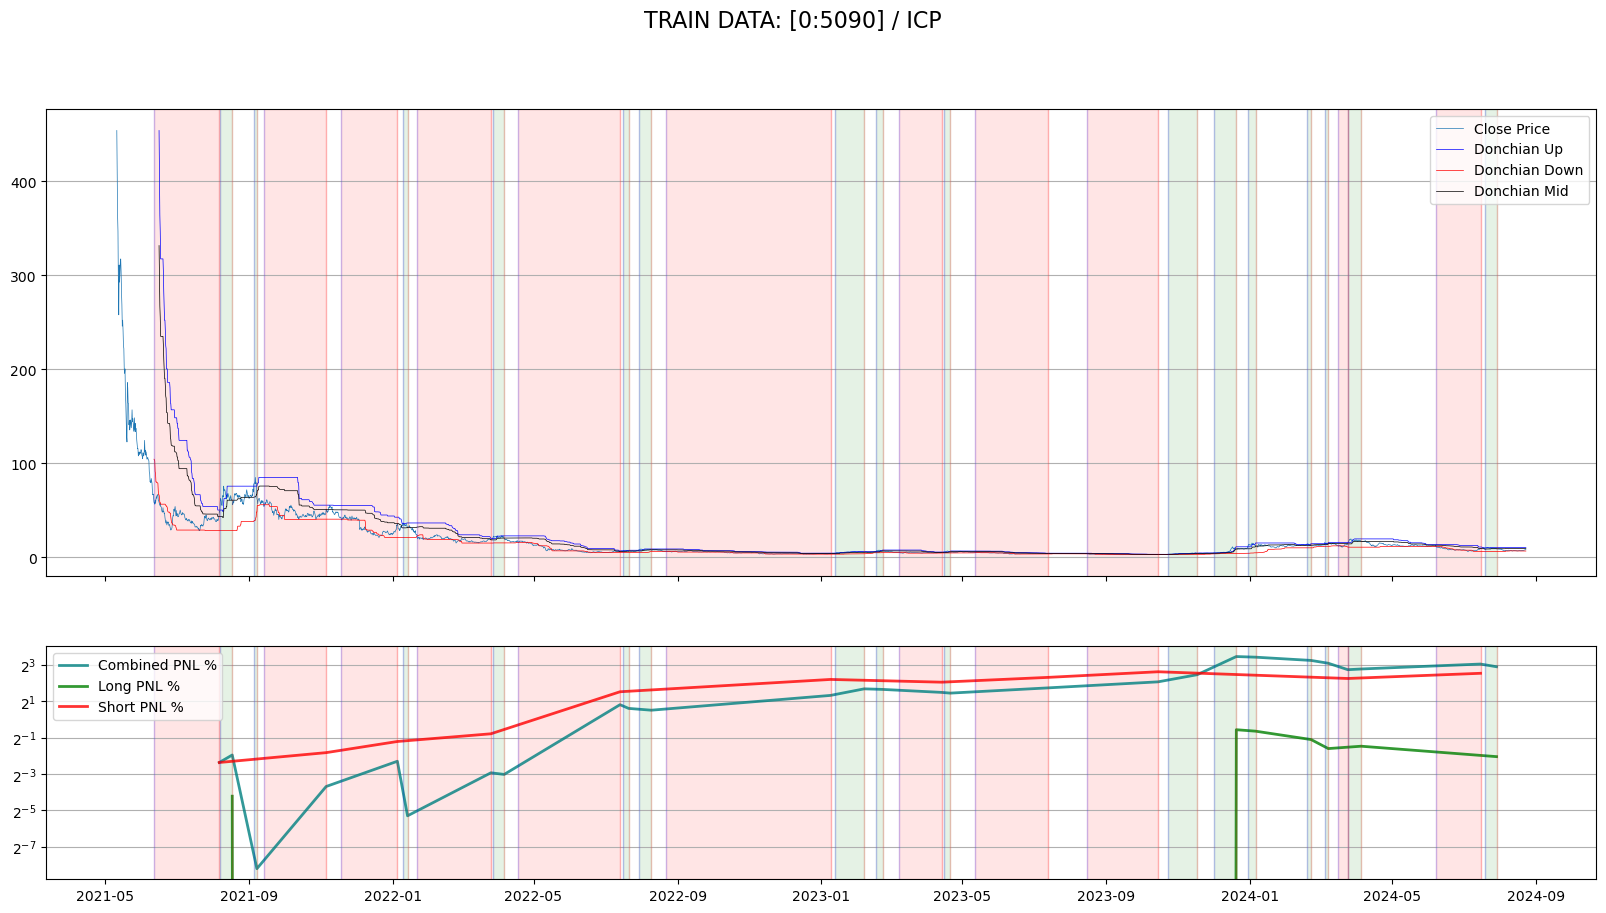

=========  KCS  /  3  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |      11086.9027 |       1376.5624 |          7.0489
Max Drawdown              |         -0.6457 |         -0.4390 |         -0.5898
N Trades                  |         62.0000 |         36.0000 |         26.0000
Sharpe Ratio              |          0.3025 |          0.3523 |          0.2157
Sortino Ratio             |          1.8477 |          4.1016 |          0.7128
Avg Return                |          0.1621 |          0.2224 |          0.0835
Max Win                   |         15.0295 |         15.0295 |          4.0968
Max Loss                  |         -0.2875 |         -0.1766 |         -0.2875
Avg Win                   |          0.5380 |          0.7998 |          0.2996
Avg Loss                  |         -0.0916 |         -0.0

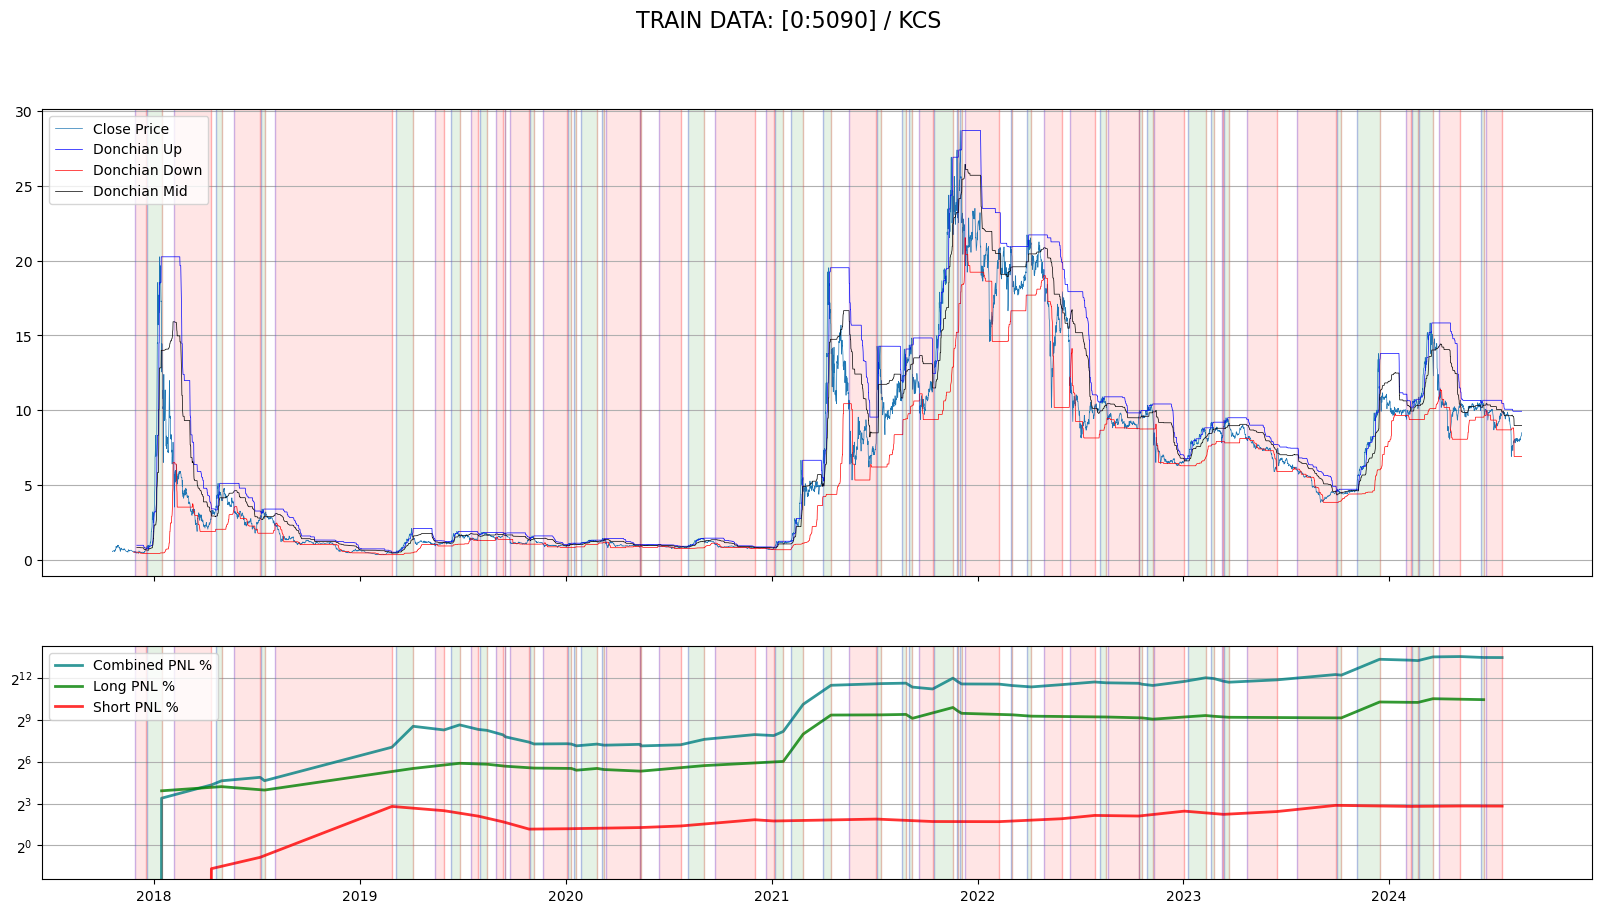

=========  KLAY  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         10.1050 |          1.0711 |          4.3618
Max Drawdown              |         -0.4742 |         -0.4068 |         -0.1835
N Trades                  |         23.0000 |         12.0000 |         11.0000
Sharpe Ratio              |          0.3056 |          0.2624 |          0.3463
Sortino Ratio             |          0.7662 |          0.2820 |          2.0975
Avg Return                |          0.1103 |          0.0626 |          0.1649
Max Win                   |          3.0840 |          0.5402 |          3.0840
Max Loss                  |         -0.3634 |         -0.3634 |         -0.1835
Avg Win                   |          0.2679 |          0.1603 |          0.4482
Avg Loss                  |         -0.1342 |         -0.

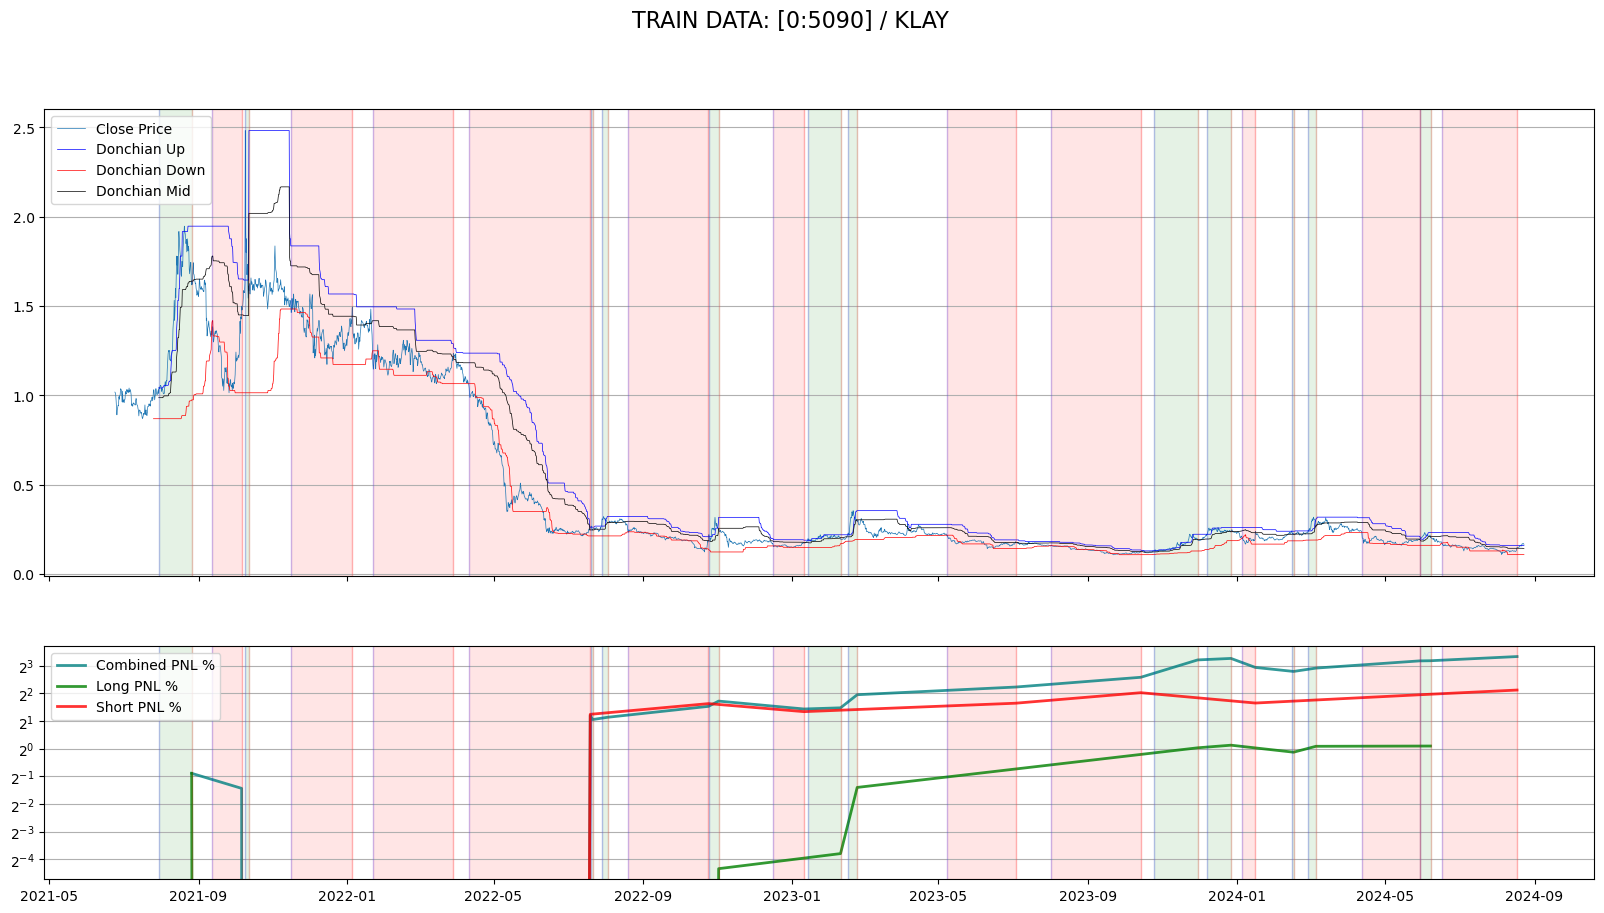

=========  MANA  /  0  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         22.0844 |          4.3773 |          3.2930
Max Drawdown              |         -0.3344 |         -0.3912 |         -0.2806
N Trades                  |         42.0000 |         27.0000 |         15.0000
Sharpe Ratio              |          0.2727 |          0.2127 |          0.3975
Sortino Ratio             |          1.2855 |          1.1296 |          1.3953
Avg Return                |          0.0776 |          0.0643 |          0.1020
Max Win                   |          1.7631 |          1.7631 |          1.0387
Max Loss                  |         -0.1804 |         -0.1623 |         -0.1804
Avg Win                   |          0.3825 |          0.4501 |          0.3102
Avg Loss                  |         -0.0903 |         -0.

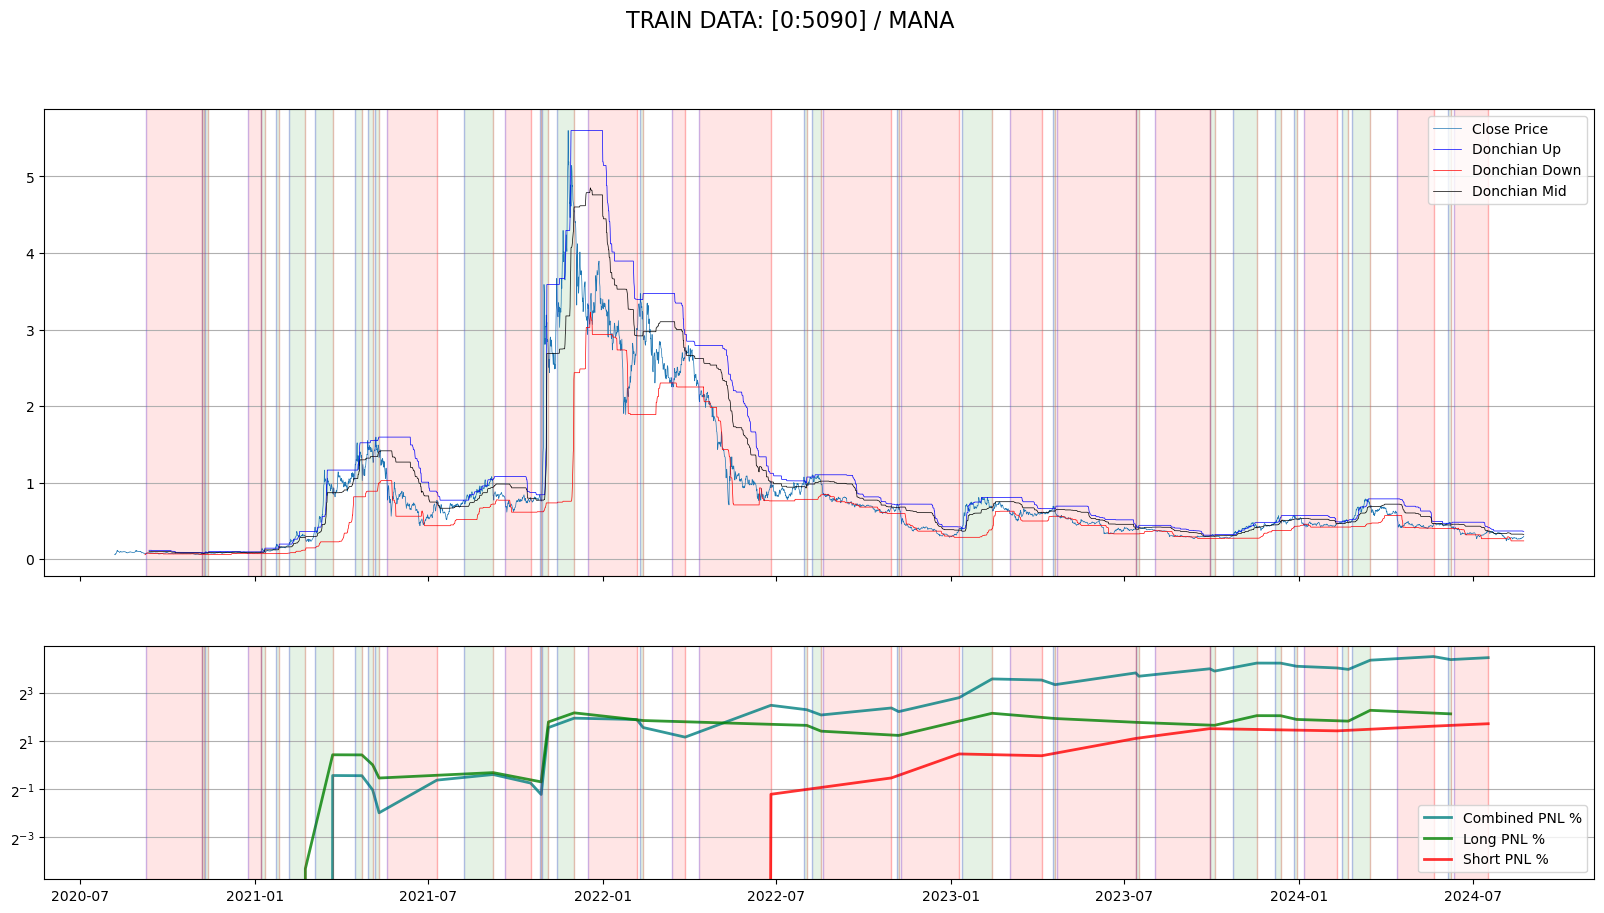

=========  MATIC  /  3  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         28.1897 |         19.6652 |          0.4125
Max Drawdown              |         -0.4698 |         -0.4615 |         -0.5107
N Trades                  |         54.0000 |         34.0000 |         20.0000
Sharpe Ratio              |          0.1765 |          0.2241 |          0.0645
Sortino Ratio             |          0.7240 |          1.4577 |          0.1775
Avg Return                |          0.0645 |          0.0932 |          0.0174
Max Win                   |          7.6465 |          7.6465 |          1.2406
Max Loss                  |         -0.2869 |         -0.2480 |         -0.2869
Avg Win                   |          0.3188 |          0.3366 |          0.2878
Avg Loss                  |         -0.1151 |         -0

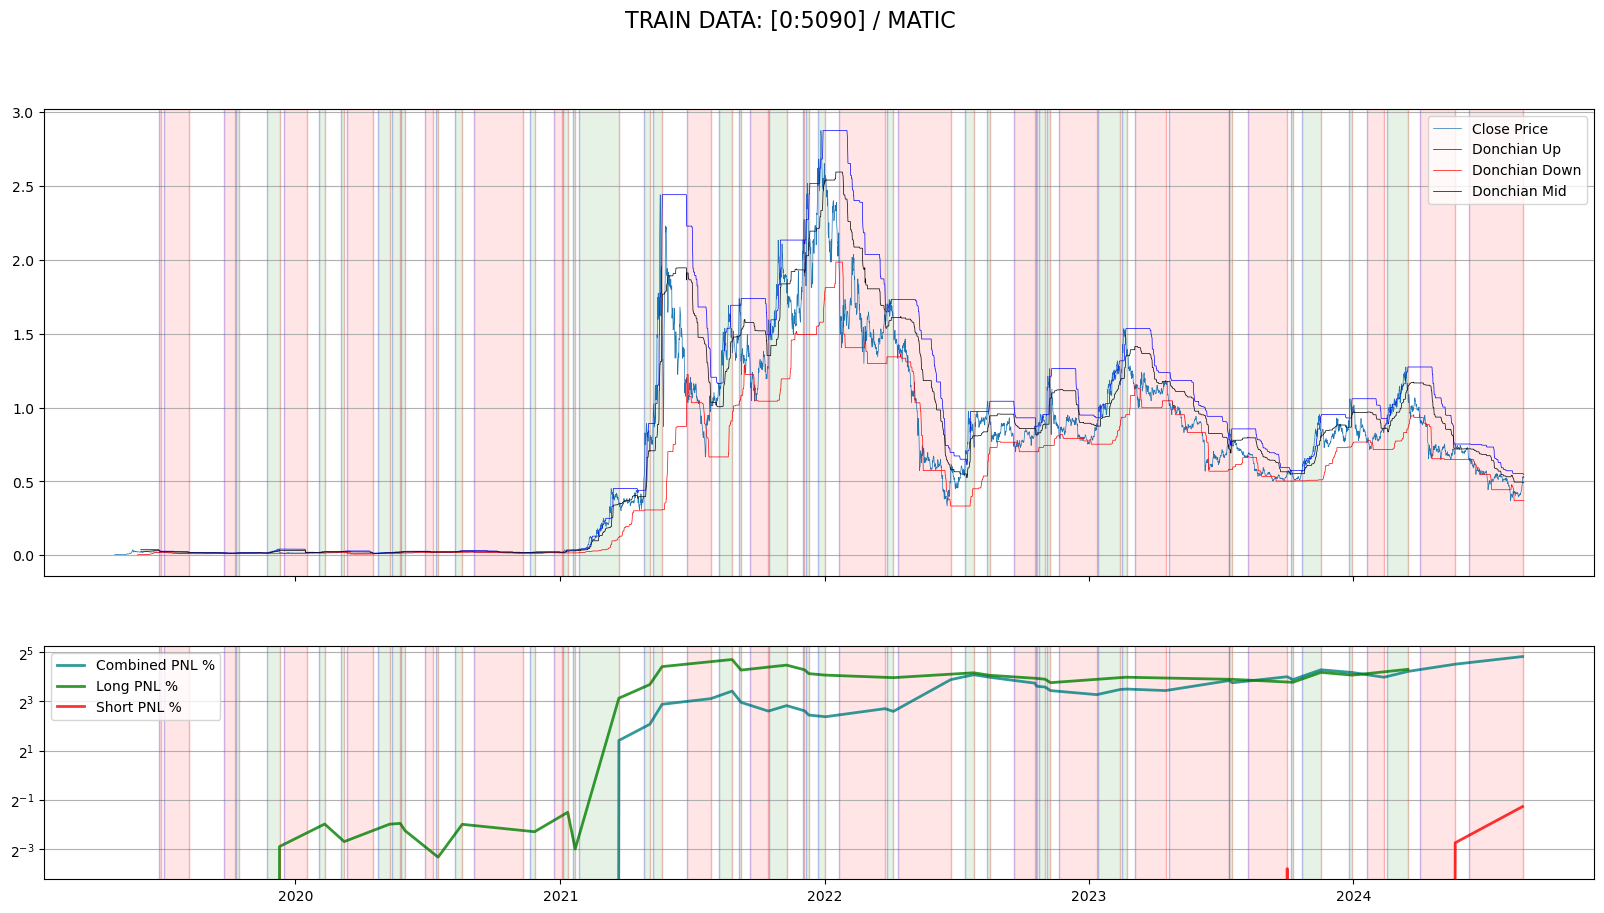

=========  NEAR  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         63.7962 |          9.1352 |          5.3932
Max Drawdown              |         -0.3117 |         -0.1738 |         -0.2959
N Trades                  |         37.0000 |         25.0000 |         12.0000
Sharpe Ratio              |          0.3663 |          0.4267 |          0.3420
Sortino Ratio             |          1.1779 |          1.8316 |          1.5262
Avg Return                |          0.1193 |          0.0971 |          0.1672
Max Win                   |          2.0272 |          0.9699 |          2.0272
Max Loss                  |         -0.3117 |         -0.1738 |         -0.3117
Avg Win                   |          0.2789 |          0.2116 |          0.4347
Avg Loss                  |         -0.1521 |         -0.

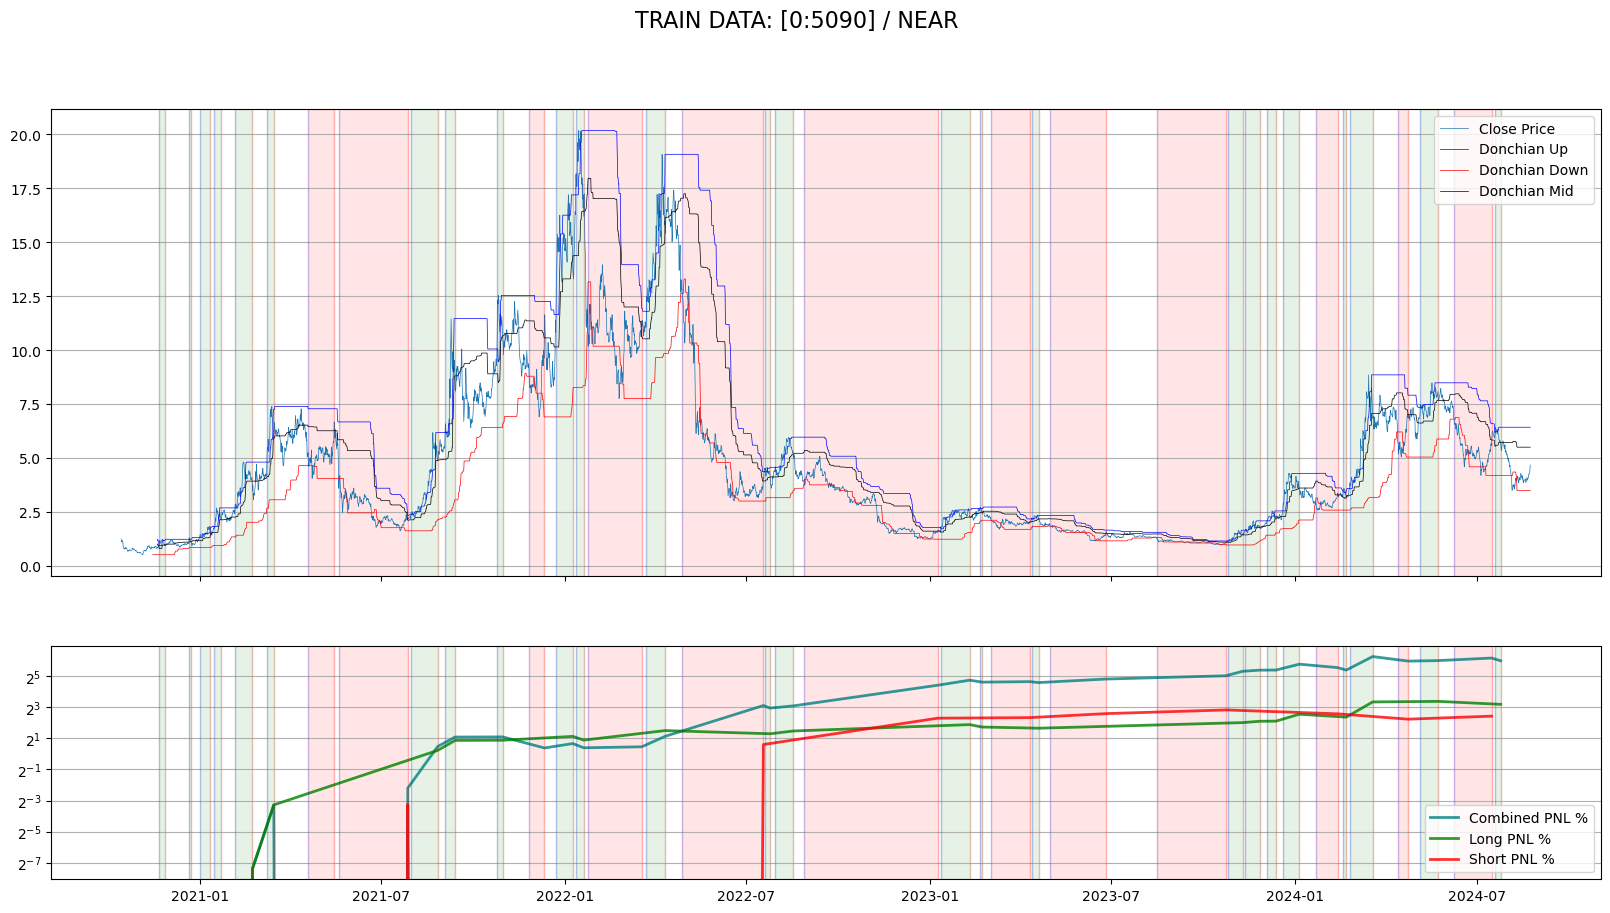

=========  OSMO  /  3  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         34.2389 |          3.8531 |          6.2611
Max Drawdown              |         -0.1641 |         -0.0748 |         -0.0965
N Trades                  |         10.0000 |          4.0000 |          6.0000
Sharpe Ratio              |          0.6249 |          0.4654 |          0.8508
Sortino Ratio             |         23.4453 |        120.3611 |          0.0000
Avg Return                |          0.4279 |          0.4842 |          0.3916
Max Win                   |          4.2789 |          4.2789 |          1.7428
Max Loss                  |         -0.0965 |         -0.0748 |         -0.0965
Avg Win                   |          0.7245 |          1.3756 |          0.5171
Avg Loss                  |         -0.0807 |         -0.

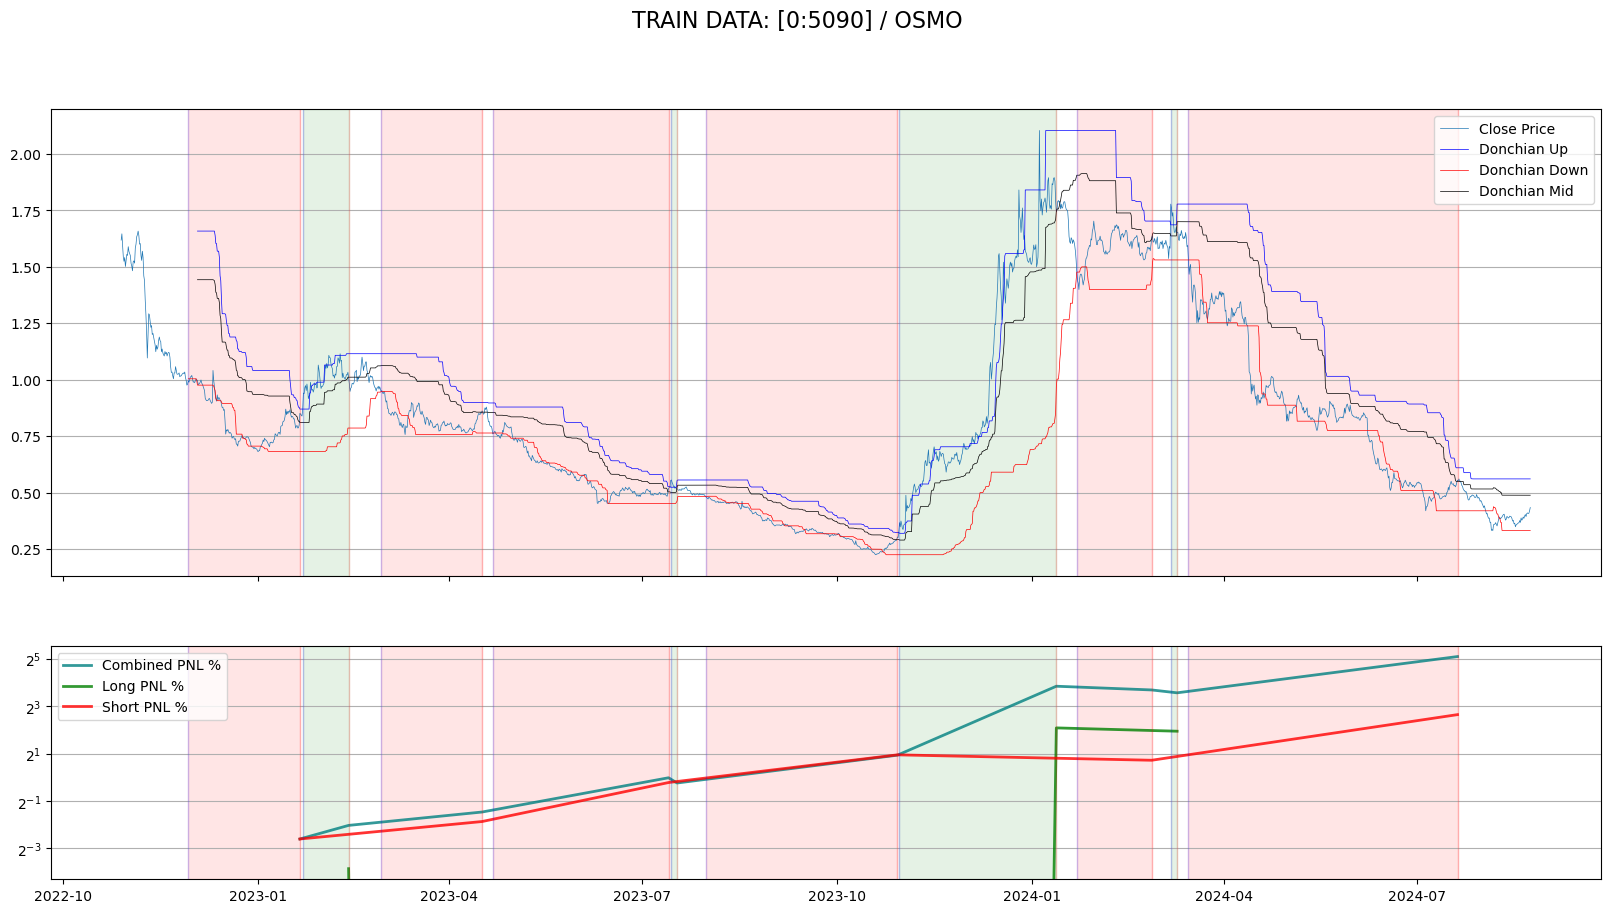

=========  RNDR  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         18.5538 |          7.3806 |          1.3332
Max Drawdown              |         -0.2892 |         -0.2358 |         -0.5224
N Trades                  |         22.0000 |         14.0000 |          8.0000
Sharpe Ratio              |          0.3339 |          0.4772 |          0.1928
Sortino Ratio             |          1.5600 |          5.0137 |          1.1511
Avg Return                |          0.1447 |          0.1640 |          0.1117
Max Win                   |          3.0876 |          1.5138 |          3.0876
Max Loss                  |         -0.2501 |         -0.1162 |         -0.2501
Avg Win                   |          0.3836 |          0.3285 |          0.5160
Avg Loss                  |         -0.1295 |         -0.

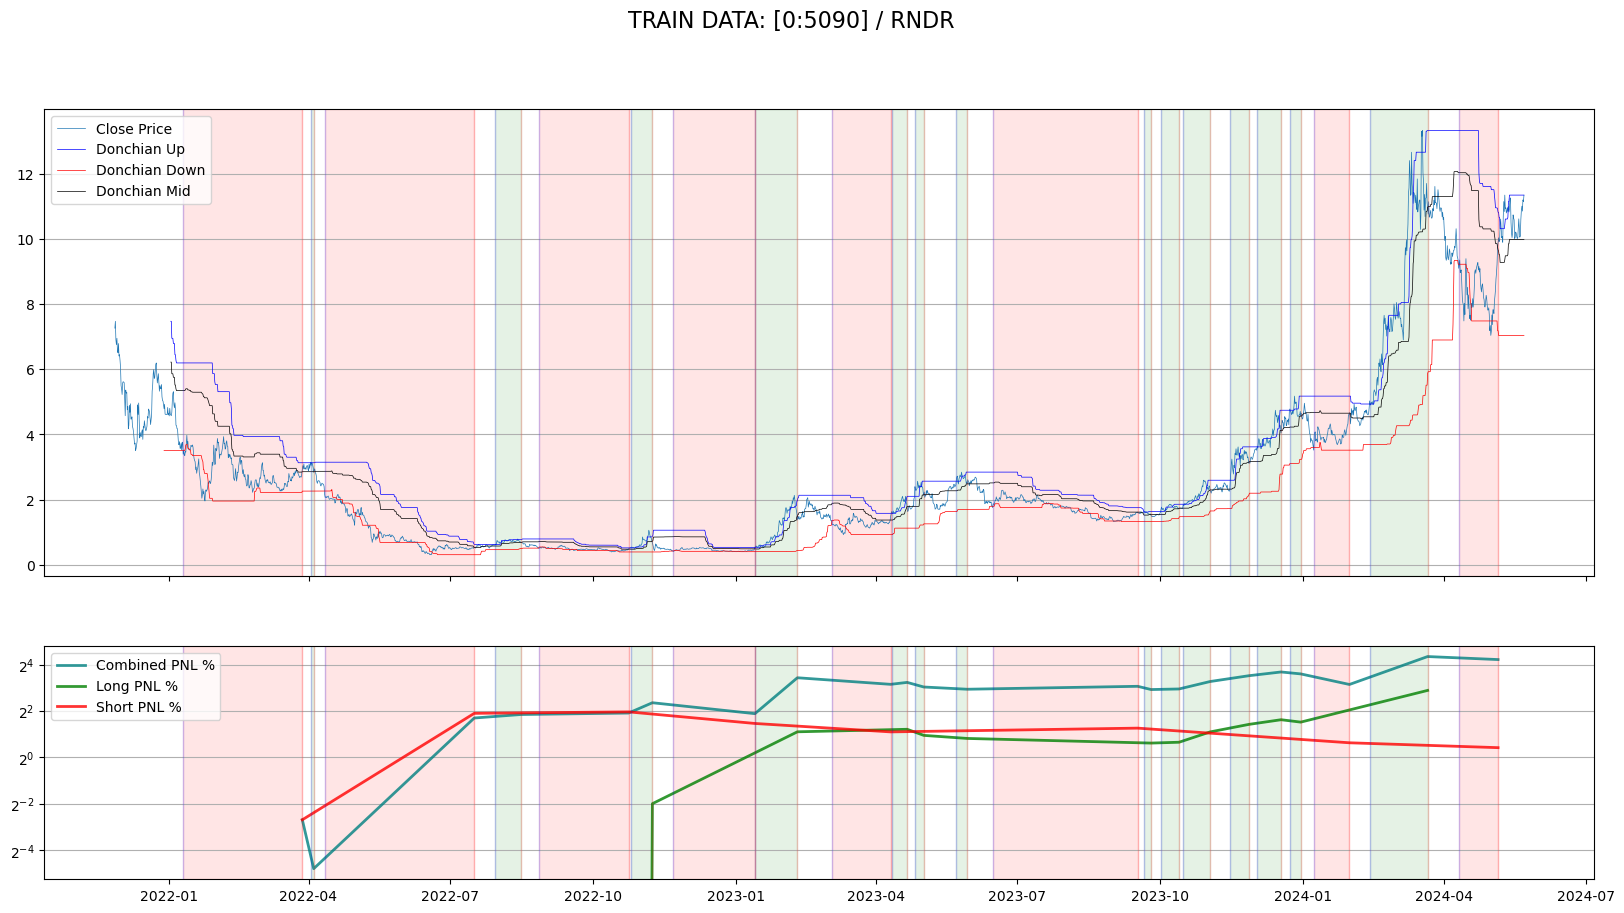

=========  ROSE  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         25.9426 |          1.3557 |         10.4371
Max Drawdown              |         -0.5838 |         -0.6661 |         -0.2098
N Trades                  |         43.0000 |         33.0000 |         10.0000
Sharpe Ratio              |          0.2549 |          0.1227 |          0.5178
Sortino Ratio             |          0.8801 |          0.2942 |         39.1842
Avg Return                |          0.0796 |          0.0263 |          0.2759
Max Win                   |          3.0041 |          0.9792 |          3.0041
Max Loss                  |         -0.3239 |         -0.3239 |         -0.1765
Avg Win                   |          0.3005 |          0.2357 |          0.4220
Avg Loss                  |         -0.1116 |         -0.

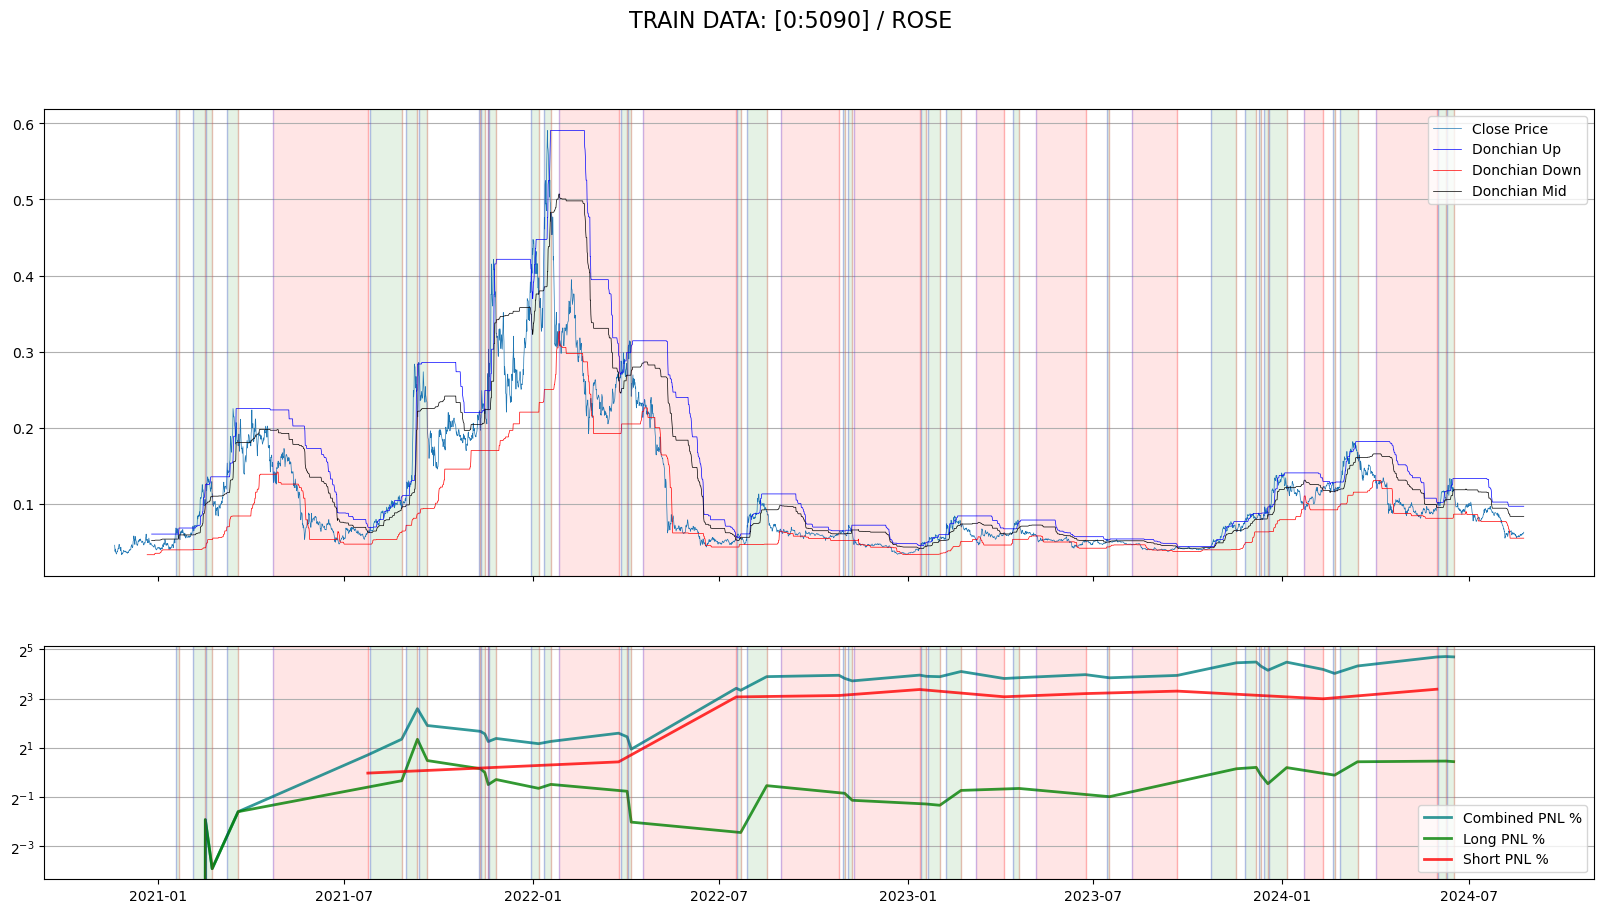

=========  RUNE  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         15.8836 |          1.4735 |          5.8258
Max Drawdown              |         -0.5134 |         -0.4616 |         -0.3512
N Trades                  |         49.0000 |         34.0000 |         15.0000
Sharpe Ratio              |          0.1864 |          0.1139 |          0.2924
Sortino Ratio             |          0.5906 |          0.4160 |          0.8478
Avg Return                |          0.0594 |          0.0270 |          0.1366
Max Win                   |          2.4467 |          1.2021 |          2.4467
Max Loss                  |         -0.3512 |         -0.2225 |         -0.3512
Avg Win                   |          0.3711 |          0.3245 |          0.4358
Avg Loss                  |         -0.1270 |         -0.

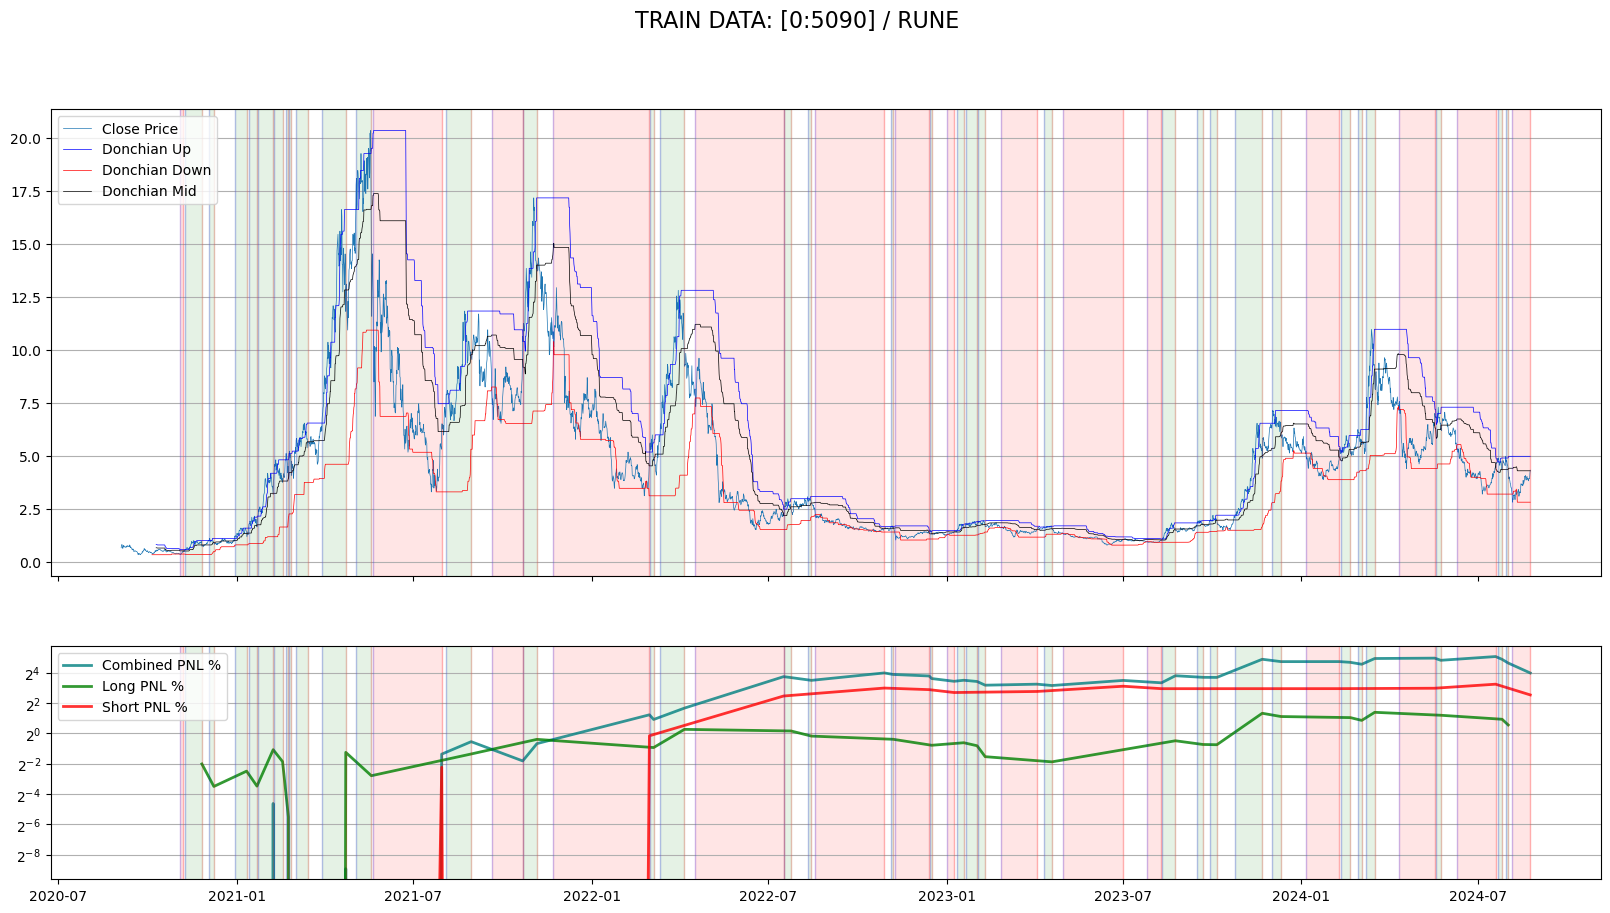

=========  SAND  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |          4.1446 |          4.7655 |         -0.1077
Max Drawdown              |         -0.6906 |         -0.5017 |         -0.7353
N Trades                  |         45.0000 |         26.0000 |         19.0000
Sharpe Ratio              |          0.1258 |          0.2174 |         -0.0230
Sortino Ratio             |          0.3895 |          0.9438 |         -0.0549
Avg Return                |          0.0371 |          0.0697 |         -0.0060
Max Win                   |          1.7392 |          1.7392 |          1.0857
Max Loss                  |         -0.2833 |         -0.2442 |         -0.2833
Avg Win                   |          0.3585 |          0.5092 |          0.2229
Avg Loss                  |         -0.1338 |         -0.

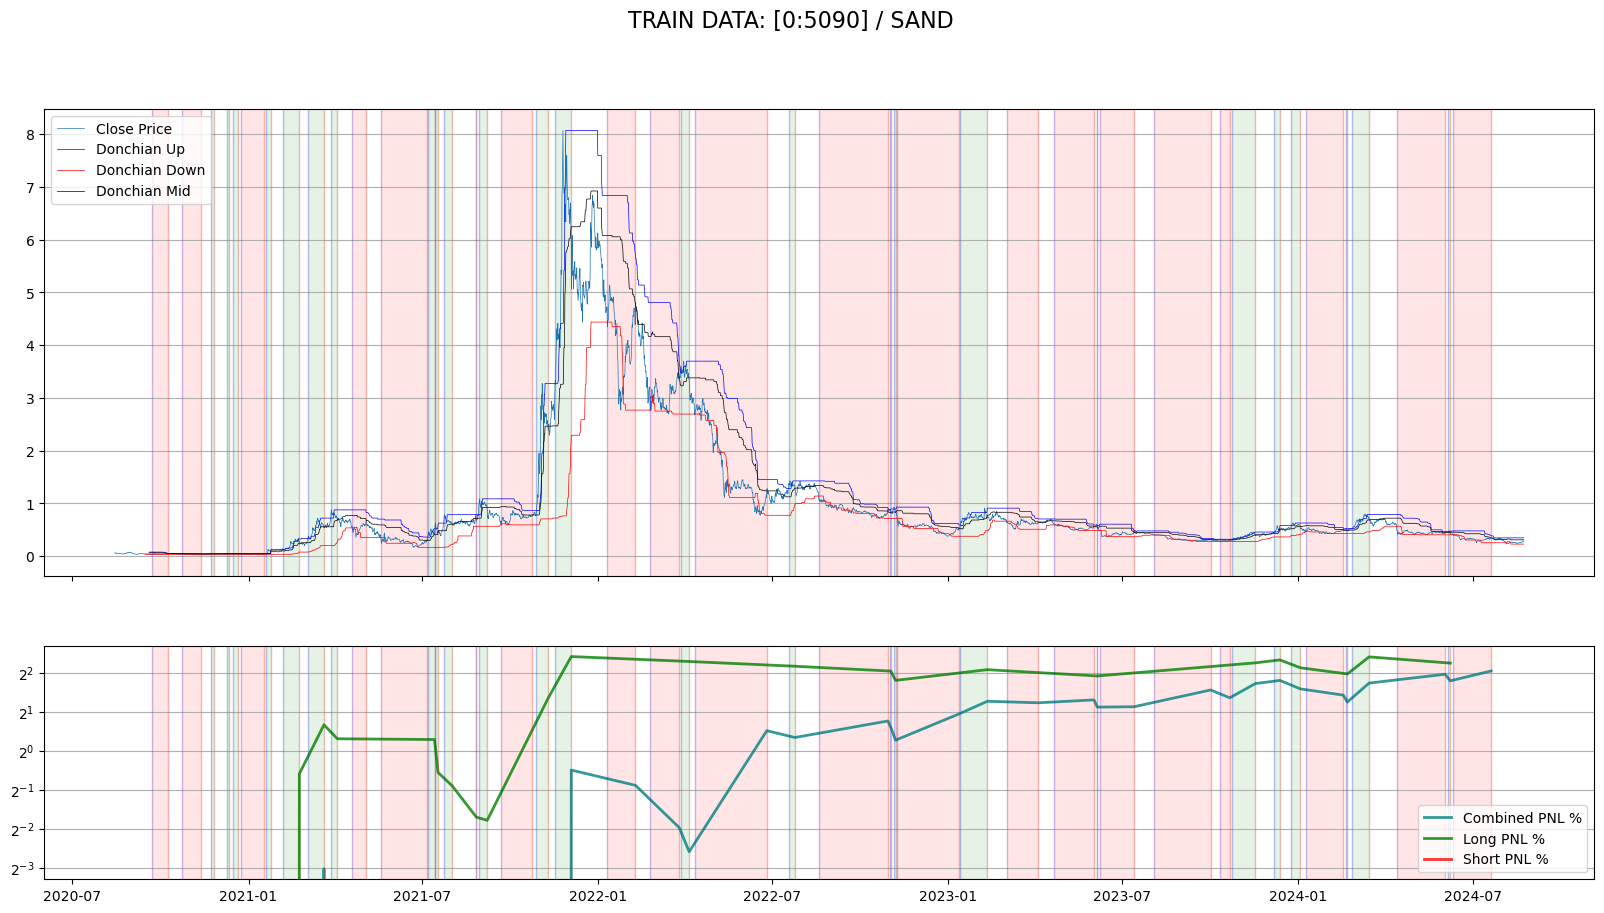

=========  SHIB  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |          7.5587 |          9.6529 |         -0.1966
Max Drawdown              |         -0.5287 |         -0.2598 |         -0.5164
N Trades                  |         30.0000 |         17.0000 |         13.0000
Sharpe Ratio              |          0.1751 |          0.2866 |         -0.0617
Sortino Ratio             |          0.6160 |          2.5108 |         -0.1130
Avg Return                |          0.0742 |          0.1493 |         -0.0167
Max Win                   |          4.3796 |          4.3796 |          0.9135
Max Loss                  |         -0.3364 |         -0.1610 |         -0.3364
Avg Win                   |          0.3891 |          0.5660 |          0.2077
Avg Loss                  |         -0.1175 |         -0.

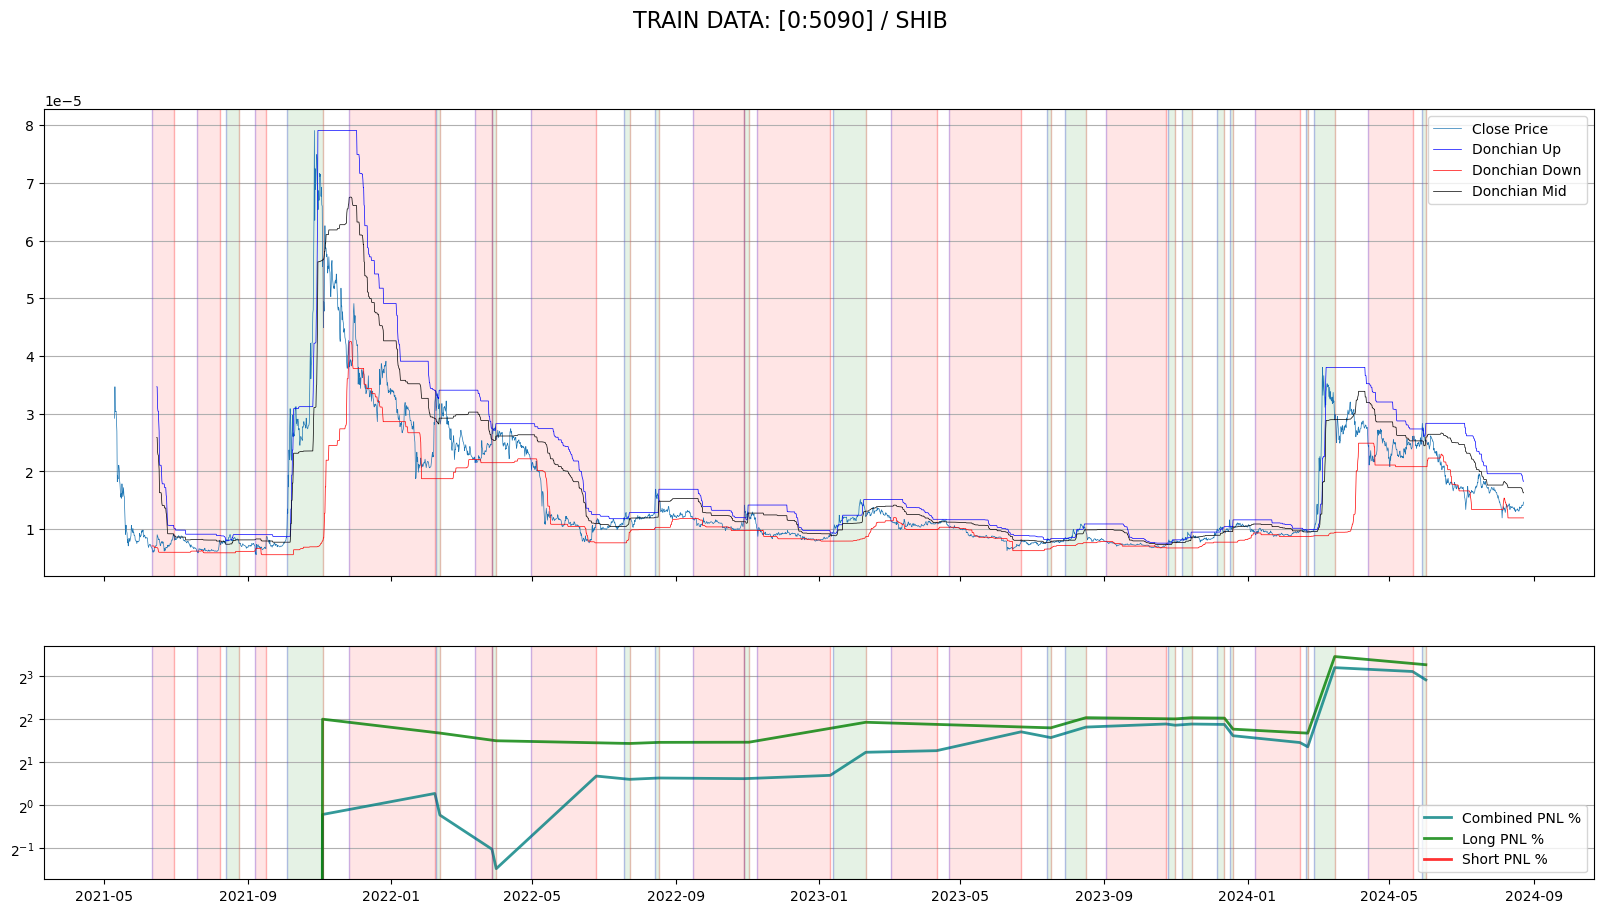

=========  SOL  /  1  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        370.1605 |         76.2142 |          3.8069
Max Drawdown              |         -0.3748 |         -0.3109 |         -0.3449
N Trades                  |         38.0000 |         25.0000 |         13.0000
Sharpe Ratio              |          0.3888 |          0.4075 |          0.3372
Sortino Ratio             |          1.6330 |          1.5260 |          2.1814
Avg Return                |          0.1685 |          0.1899 |          0.1284
Max Win                   |          3.1449 |          3.1449 |          1.4746
Max Loss                  |         -0.3109 |         -0.3109 |         -0.1785
Avg Win                   |          0.4568 |          0.4915 |          0.3900
Avg Loss                  |         -0.1102 |         -0.1

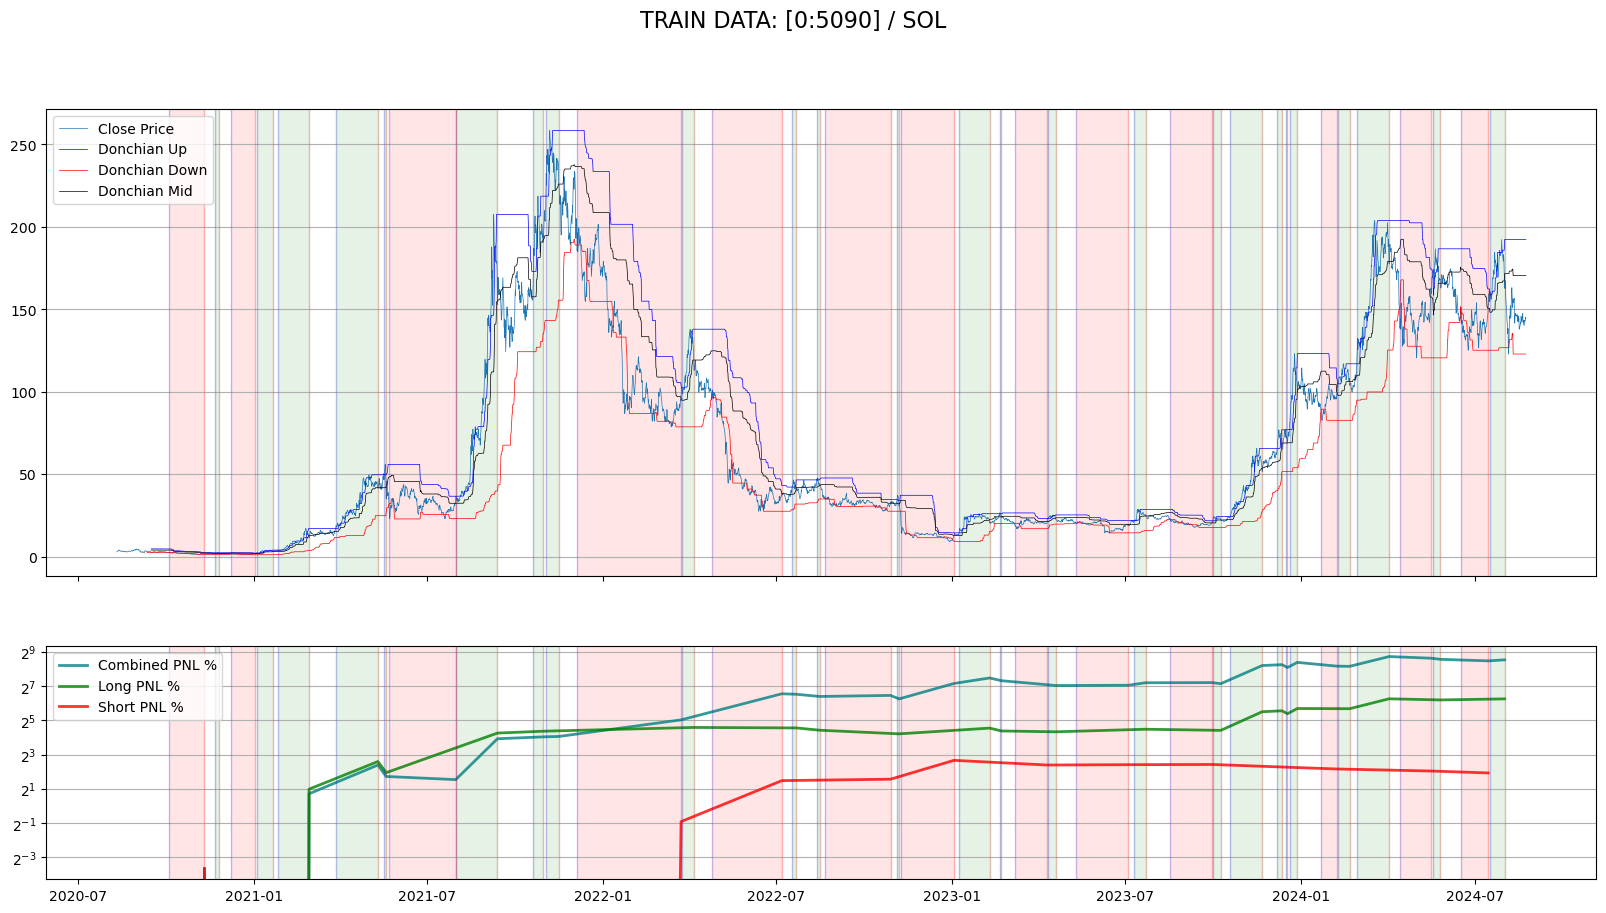

=========  VET  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |        746.5318 |         27.6732 |         25.0708
Max Drawdown              |         -0.5213 |         -0.2479 |         -0.4056
N Trades                  |         57.0000 |         36.0000 |         21.0000
Sharpe Ratio              |          0.3508 |          0.3013 |          0.4202
Sortino Ratio             |          1.4871 |          1.8394 |          1.5005
Avg Return                |          0.1231 |          0.0977 |          0.1680
Max Win                   |          2.3223 |          2.3223 |          1.5059
Max Loss                  |         -0.3098 |         -0.1717 |         -0.3098
Avg Win                   |          0.3573 |          0.2854 |          0.4862
Avg Loss                  |         -0.1187 |         -0.0

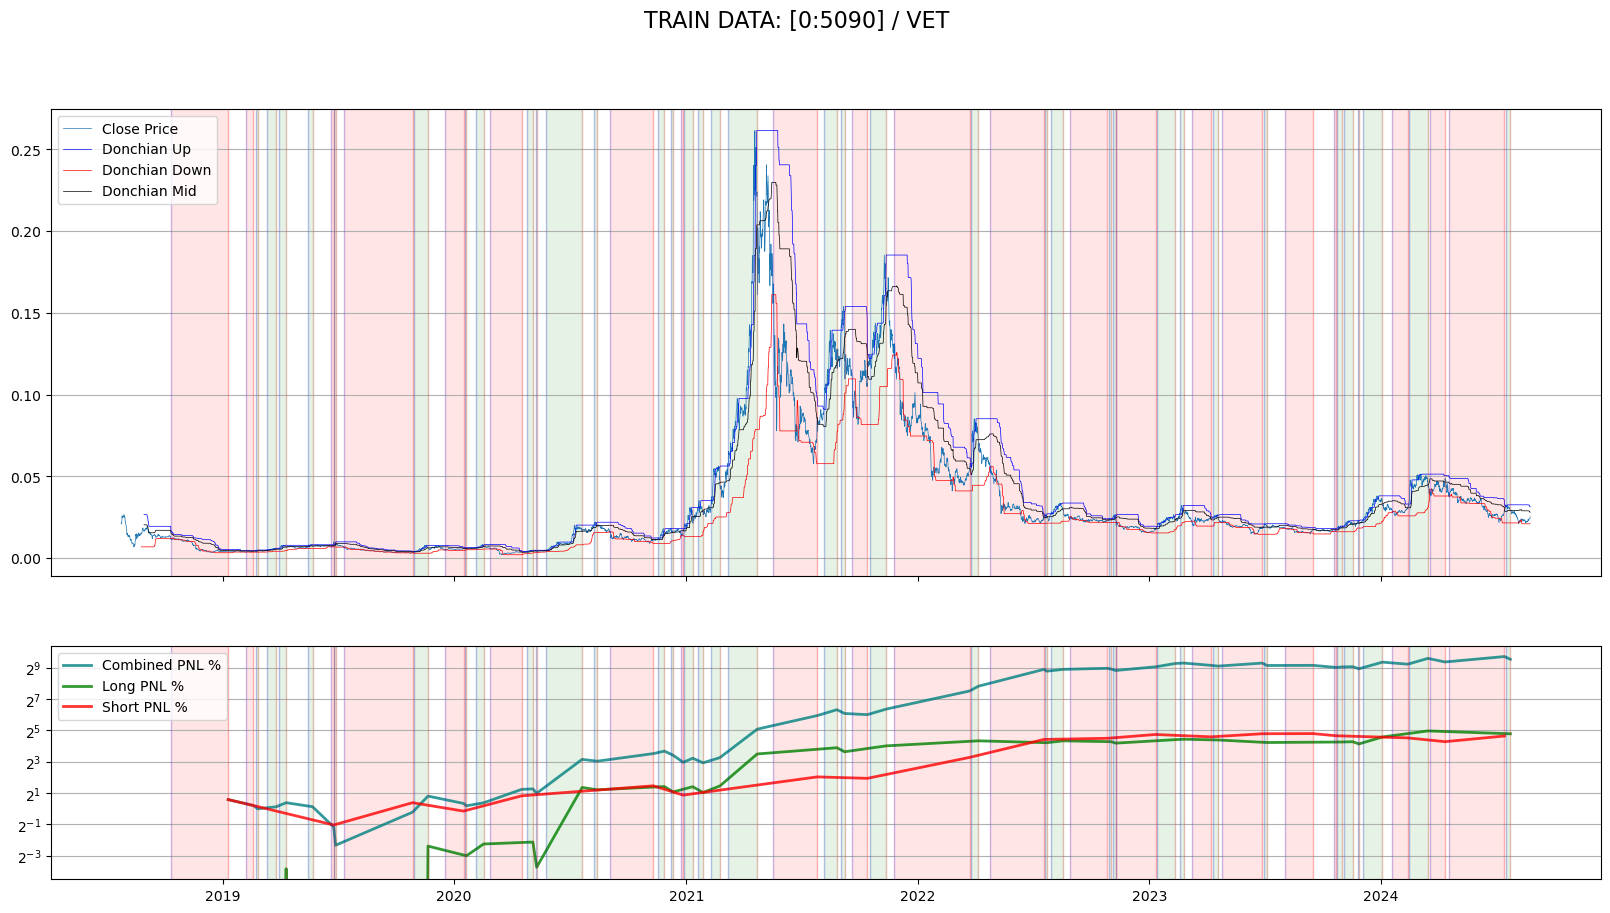

=========  WEMIX  /  2  /  8h  ===============================
Metric                    |         Overall |  Long Positions | Short Positions
--------------------------------------------------------------------------------
Tot Return                |         15.4522 |          5.9568 |          1.3649
Max Drawdown              |         -0.3862 |         -0.1207 |         -0.3020
N Trades                  |         15.0000 |          9.0000 |          6.0000
Sharpe Ratio              |          0.5666 |          0.6543 |          0.4031
Sortino Ratio             |          1.3292 |          3.6381 |          0.5775
Avg Return                |          0.2053 |          0.2405 |          0.1543
Max Win                   |          1.4896 |          1.4896 |          0.8932
Max Loss                  |         -0.3020 |         -0.1207 |         -0.3020
Avg Win                   |          0.4110 |          0.4465 |          0.3595
Avg Loss                  |         -0.1206 |         -0

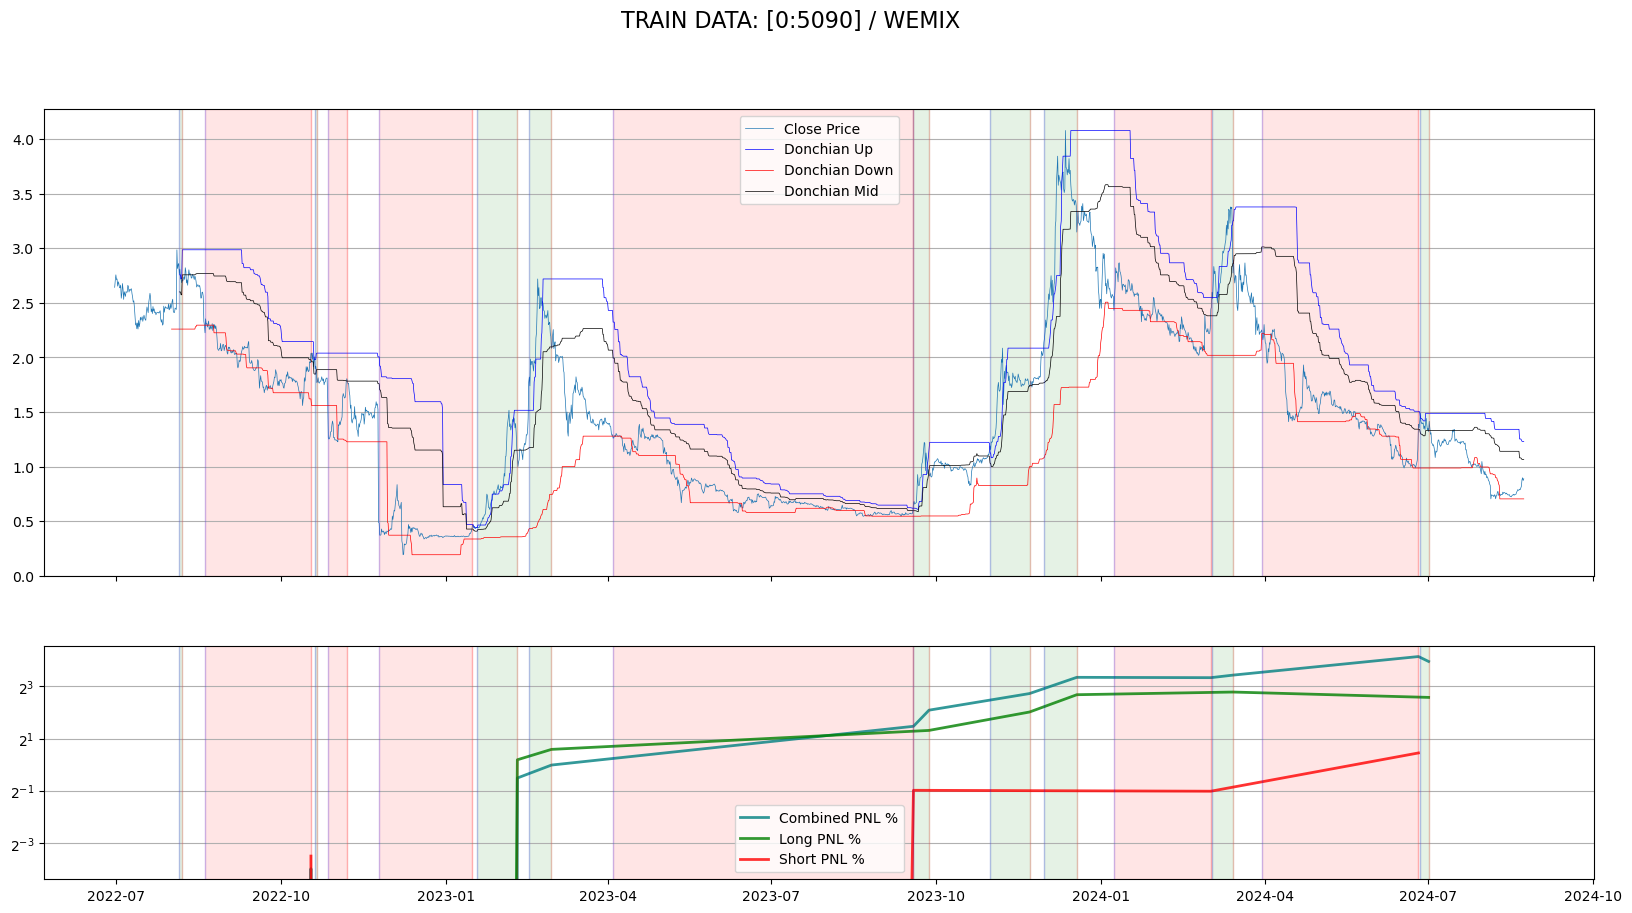

In [25]:
for ix, exchange, asset, ipa, tfr in df[['exchange','asset','ipa','tfr']].to_records():
    print(f'=========  {asset}  /  {ipa}  /  {tfr}  ===============================')
    data = load_candles(exchange,asset,quote,tfr)#['2021':]
    fig_tr,res_tr = plot_performance(data,asset,params, indicators=indicators, enable_short=True, signals=signals, reset_index=False, btkwargs={'xmult':1, 'slippage': 0.005, 'transaction_cost': 0.001, 'period_costs': 0.0003/6}, title=f'TRAIN DATA: [0:{data_train.shape[0]}]')

In [ ]:
[c for c in df.columns if c[0] not in ['long_metrics','short_metrics','overall_metrics'] or c[1] in ['tot_return','max_drawdown'] ]


## Randomize params and assets, test for robustness

In [ ]:
timeframe,quote,nhours ='1h', 'USDT', 4
# np.random.seed = 3
opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]


In [ ]:

rand_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
rand_backtests.sort_values('tot_return').tail()

In [ ]:
rand_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe()


In [ ]:
rand_backtests.hist(bins=50,figsize=(20,8))
plt.tight_layout()

## Simulate 100 randomized parameter set picks

In [ ]:
## Run a bunch of randomized simulations
timeframe,quote,nhours ='1h', 'USDT', 8
ran_sumul = []
for i in tqdm(range(10)):
    opt_backtests = [backtest(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':].resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}),params,nhours=nhours,short_long=[1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]
    ran_backtests = pd.DataFrame([{k:v for (k,v) in opt_bt.items() if not (isinstance(v,pd.Series) or isinstance(v,pd.Index)  or isinstance(v,np.ndarray))} for opt_bt in opt_backtests], index=df_pfexch.index)
    ran_sumul.append(ran_backtests[['tot_return_pct','trade_max_drawdown_pct']].describe().to_dict())
    
# np.histogram(ran_sumul)


In [ ]:
ran_sumul
# pd.DataFrame.from_records(ran_sumul)
# simul_rets = pd.Series(ran_sumul)
# simul_rets.describe(),simul_rets.hist(bins=50)

In [ ]:

opt_backtests = [print_performance(load_candles(asset_exch_dict[asset], asset, quote,timeframe)['2021':],nhours,params,backtest,short_long=[-1,1],xmult=1) for (asset, params) in list(zip(df_opt.index,np.random.permutation(df_opt['params'].values))) ]

## Generate pinescript for a bunch of assets

In [ ]:
assets = ['ADA', 'ALGO', 'DOT', 'LINK', 'SOL']
exchange = 'BINANCE'
def objective(trial):
    global data
    up_lookback = trial.suggest_int('up_lookback', 7, 100)
    dn_lookback = trial.suggest_int('dn_lookback', 7, 100)
    up_lag = trial.suggest_int('up_lag', 7, 100)
    dn_lag = trial.suggest_int('dn_lag', 7, 100)
    params = {
        'up_lookback': up_lookback,
        'dn_lookback': dn_lookback,
        'up_lag': up_lag,
        'dn_lag': dn_lag
    }
    res = backtest(data,params,nhours,short_long, xmult=1)
    return res['tot_return'], res['trade_max_drawdown']#/ math.cos(number_of_trades)
nhours = 1
# data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [1]
asset_params = {}
for asset in assets:
    data = load_candles('binance',asset,'USDT','8h')#['2011':'2025']#.iloc[-10000:]
    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=100)
    asset_params[f'{asset}USDT'] = study.best_trials[-1].params

In [ ]:
asset_params

In [ ]:
from jinja2 import Template
quote = 'USDT'
# Define the template (could also be loaded from a .jinja2 file)
template_str = """
//@version=5
indicator("Custom Donchian with Asset-Specific Parameters", overlay=true)

up_lag = 20
up_lookback = 20
dn_lag = 20
dn_lookback = 20
split_string = str.split(ticker.standard(),":")
string tkr = split_string.last()
// Determine parameters based on asset
{% for asset, params in asset_params.items() %}
if (tkr == "{{ asset }}{{ quote }}")
    up_lag := {{ params.up_lag }}
    dn_lag := {{ params.dn_lag }}
    up_lookback := {{ params.up_lookback }}
    dn_lookback := {{ params.dn_lookback }}
{% endfor %}

// Upper Donchian Band: Highest high over the up_lookback period, shifted by donch_up periods
upper_band = ta.highest(high, up_lookback)[up_lag]
// Lower Donchian Band: Lowest low over the dn_lookback period, shifted by donch_dn periods
lower_band = ta.lowest(low, dn_lookback)[dn_lag]
// Middle line between the upper and lower bands
middle_line = (upper_band + lower_band) / 2

// Plotting the upper and lower bands
plot(upper_band, title="Upper Donchian Band", color=color.green, linewidth=2)
plot(lower_band, title="Lower Donchian Band", color=color.red, linewidth=2)
plot(middle_line, title="Middle Line", color=color.gray, linewidth=2)

"""

template_str2 = """
bla
{% for asset in assets %}
 "{{ asset }}"
{% endfor %}
"""
# Create a template object
template = Template(template_str)

# Render the template with the asset_params dictionary
rendered_pine_script = template.render(asset_params=asset_params, quote=quote)

# Output the generated Pine Script
print(rendered_pine_script)



## Split data into training and testing set

In [ ]:
np.min([params[k] for k in params])

In [ ]:

data = load_candles('binance','BTC','USDT','1h')#.iloc[-5000:]
# data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# data = data['2021-11-01':].copy()
nhours = 8
data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
short_long = [-1,1]

train_ratio = 0.3; 
cutoff = int(train_ratio * data.shape[0])
train_data, test_data = data.iloc[:cutoff,:], data.iloc[cutoff+1-np.max([params[k] for k in params]):,:]

study = optimize(train_data, nhours,backtest_fn=backtest, short_long=short_long)
params = study.best_params
params = {'tenkan_period': 19, 'kijun_period': 22, 'senkou_span_b_period': 22}
print(f'params = {params}')
print_performance(test_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print_performance(train_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print(f'params = {params}')

In [ ]:
train_data

## Backtest in a LOOP

In [ ]:
   
def backtest(data, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    if 1 in short_long:
        data.loc[data['bull'], 'position'] = 1        
        data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    if -1 in short_long:
        data.loc[(data['bear']), 'position'] = -1    
        data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    # data['position'] = xmult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) -1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) -1
    ###
    
    
    # Apply transaction costs and slippage only on trades
    # data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / nhours)
    sharpe_ratio = annualized_return / annualized_volatility
    

## Forward Testing

In [ ]:
# data = load_futures_candles('bybit','ADA','USDT','1h')['2020':'2023']
data = load_candles('binance','BTC','USDT','1h')['2020':'2025']
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 8 ; ntrain = 3 ; ndays = 30
short_long = [1]
data = data.resample(f'{nhours}H').agg(ohlc_dict)#[:'2022']
n = data.shape[0]
w = (24 // nhours) * ndays
fwd_params = []
for i in tqdm(range(ntrain, (n // w)-1)):
    fwd_params.append(optimize(data.iloc[(i-ntrain)*w:(i)*w-1], nhours, short_long=short_long,xmult=1).best_params)
    

In [ ]:
df_params = pd.DataFrame(fwd_params)
df_params.describe()

In [ ]:


bt_arr = []; res_arr =[]
for i in tqdm(range(ntrain, (n // w)-1)):    
    # print(i)
    wdata = indicators(data.iloc[i*w:(i+1)*w],fwd_params[i-ntrain])
    results = backtest(wdata,nhours,short_long)
    decorate_trades(wdata)
    bt_arr.append(wdata)
    res_arr.append(results)

In [ ]:
data.shape[0], w, i, i*w, (i+1)*w

In [ ]:
df_res = pd.DataFrame(res_arr)
df_res#.describe()

In [ ]:
df_res.sharpe_ratio.mean(), (1+df_res.total_return).cumprod().values[-1], df_res.number_of_trades.sum()

In [ ]:
df_trd = pd.concat(bt_arr)
ax = df_trd['pct_strategy_returns'].add(1).cumprod().subtract(1).plot()
# df_trd['pct_cumulative_returns'].plot(ax=ax)

In [ ]:
df_trd

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(f'{8}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

## Test different Timeframes with resampling

In [ ]:
data = load_candles('ALGO','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


In [ ]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

In [ ]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
i = 6
data = data.resample(f'{resample_periods[i]}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
